# GraphSentinel — Training

A self-healing cyber defence system using graph deep learning and immutable
audit trails. This notebook trains the detection model: CICIDS2017 flows →
host-communication graph → GATv2 encoder → flow-level attack classification →
exported artefacts for the backend.

**Run the sections in order.** Section 1 through 4 are setup and are safe to
re-run at any time. Section 5 is the long one.

### What changed from the previous notebook

| Problem | Fix |
|---|---|
| `LITE_MODE` silently trained on 2 of 5 capture days, and its results were reported as real | Removed. `QUICK` cuts epochs only, never the dataset |
| Two config cells competing; whichever ran last won | One config cell. Nothing downstream rebuilds `cfg` |
| Verification could be pointed at the wrong dataset | Verification rebuilds `cfg` from the checkpoint |
| A non-finite loss silently discarded 20.9% of training windows, costing 100% of DDoS, PortScan and Botnet while the printed loss read `0.0001` | fp32 retry, per-epoch drop report, and an abort if any class loses >2% of its edges |
| Debug cells with load-bearing execution order | Removed. Run All from the top is always correct |

### Before you start
Runtime → Change runtime type → **T4 GPU**. You will need
`graphsentinel_v2.zip` to hand for section 2.

### What Run All does, and what it does not

`Runtime → Run all` from the top is safe. Four cells are **gated** — they open
with `RUN_THIS = False` and stop themselves with a clear *SKIPPED* message
rather than blocking or burning an hour. Flip the flag when you want one.

| section | cell | ⏱ | gated? |
|---|---|---|---|
| 1 · Environment | mount, cleanup (dry run), BASE, GPU, deps | <1 min | no |
| 2 · Package | 2.1 upload a new zip | — | **yes** — opens a file picker |
| | 2.2 load the package | <1 min | no |
| 3–6 · Config, data, graphs | validate, label audit, build, topology | 2–15 min | no |
| 7 · Train | 7.1 train | ~25 min | no |
| | 7.2 recover history | — | `RECOVER = False` |
| 8–10 · Export, verify, SDN | artefacts, 9.1, 9.2, inference | ~10 min | no |
| 11 · Thresholds | 11.1 held-out + operating points | 10–20 min | no |
| 12 · What it reads | 12.1 ablation, 12.2 confirm + LOO | ~10 min | no |
| 13 · Ablation matrix | 13.1 four retrains | **~100 min** | **yes** |
| 14 · Baseline | RandomForest vs GNN | ~5 min | no |
| 15 · Storage | 15.1 copy to Drive | ~2 min | no |
| | 15.2 download to your machine | — | **yes** — browser download |
| | 15.3 Drive health | ~3 min | **yes** — diagnostic only |

A full Run All is roughly **70–90 minutes** and ends with a trained, verified,
exported model plus every table in sections 11, 12 and 14.

### Read the order of evidence

Sections 9 and 11 describe *this* checkpoint. Section 12 cripples it at
inference to see what it depends on — that is out-of-distribution behaviour,
**not** evidence about what a differently trained model would learn. Only
section 13 retrains, and only section 14 can tell you whether a graph model
was needed at all. Do not quote a section-12 number as a result.

## 1 · Environment

In [125]:
# 1.1 — MOUNT DRIVE
# WHY: mount Drive. Separated from BASE detection so the cleanup cell below
# can run even when the layout is too broken for detection to succeed -- which
# is exactly when you need the cleanup.
from google.colab import drive
drive.mount("/content/drive", force_remount=False)
print("Drive mounted.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted.


In [ ]:
# 1.2 — DRIVE CLEANUP (dry run by default).
#        Run this BEFORE BASE detection: it fixes the layout that detection
#        depends on. Read the plan, then set CONFIRM = 'CLEAN' and re-run.
# ============================================================================
#  DRIVE CLEANUP -- fix the layout and remove everything that can corrupt a run
#
#  DRY RUN BY DEFAULT. Nothing is touched until you set CONFIRM = "CLEAN".
#  Read the plan it prints first.
#
#  WHAT WENT WRONG
#  Your BASE detection resolved to:
#      /content/drive/MyDrive/GraphsentinalV2/graphsentinel     <- WRONG
#  because the package is currently nested one level too deep:
#      GraphsentinalV2/graphsentinel/graphsentinel/config.py
#  The finder looks for */graphsentinel/config.py and took the first match,
#  which made BASE the inner project folder -- which has no datasets/.
#
#  That nesting is my fault: graphsentinel_v2.zip has a top-level directory
#  ALSO called `graphsentinel`, so extracting it inside a folder named
#  graphsentinel/ produces graphsentinel/graphsentinel/. Fixed in the next zip.
#
#  WHAT THIS SCRIPT DOES
#    1. flattens the nested package so config.py sits at BASE/graphsentinel/
#    2. deletes leftovers that shadow or confuse imports
#    3. deletes every artefact produced by the five VOID training runs
#    4. PRESERVES all datasets -- including the Thursday captures, which are
#       the unseen-family holdout and must not be thrown away
# ============================================================================
import os, glob, shutil, json

CONFIRM = ""          # <-- set to "CLEAN" to actually perform the plan

# ---------------------------------------------------------------- locate ----
ROOT = "/content/drive/MyDrive/GraphsentinalV2"
if not os.path.isdir(ROOT):
    cands = [d for d in glob.glob("/content/drive/MyDrive/*")
             if os.path.isdir(os.path.join(d, "datasets"))]
    assert cands, "Could not find the project folder. Set ROOT by hand."
    ROOT = cands[0]
print(f"project root: {ROOT}\n")

plan = []      # (action, path, why)


def note(action, path, why):
    plan.append((action, path, why))


# ---- 1. is the package nested one level too deep? ------------------------
pkg_direct = os.path.join(ROOT, "graphsentinel", "config.py")
pkg_nested = os.path.join(ROOT, "graphsentinel", "graphsentinel", "config.py")
NESTED = os.path.isfile(pkg_nested) and not os.path.isfile(pkg_direct)

if NESTED:
    note("FLATTEN", os.path.join(ROOT, "graphsentinel"),
         "package is at graphsentinel/graphsentinel/ -- BASE detection lands on "
         "the inner folder, which has no datasets/. Move the package up one "
         "level and lift tests/ and docs/ to the project root.")
elif os.path.isfile(pkg_direct):
    print("  layout OK: graphsentinel/config.py is already at the right depth")
else:
    raise SystemExit(f"No graphsentinel/config.py found under {ROOT} at all.")

# ---- 2. leftovers that shadow imports or confuse the finder --------------
for rel, why in [
    ("_graphsentinel_backup", "old package copy left by install_package.py; "
                              "a stale duplicate is how the wrong code gets imported"),
    ("_promote_tmp",          "empty scratch directory from an earlier move"),
    ("recon.py",              "stray copy of graphsentinel/models/recon.py at the "
                              "project root; shadows nothing today but will the "
                              "moment something adds ROOT to sys.path"),
]:
    p = os.path.join(ROOT, rel)
    if os.path.exists(p):
        note("DELETE", p, why)

# ---- 3. artefacts of the five void runs ---------------------------------
# Every one of these was produced by the training loop that silently discarded
# 20.9% of windows, costing 100% of DDoS, PortScan and Botnet. Keeping any of
# them risks a resume continuing from a poisoned checkpoint or a verification
# reading a stale report.
VOID = [
    (os.path.join(ROOT, "checkpoints"), "*.pt",
     "trained by the loop that dropped 3 whole classes; a resume would continue "
     "from it"),
    (os.path.join(ROOT, "models"), "*",
     "exported FROM that checkpoint -- weights, model card, ONNX, TorchScript, "
     "scalers"),
    (os.path.join(ROOT, "logs"), "*",
     "training_log.csv has no windows_dropped column, so it cannot distinguish "
     "'nothing dropped' from 'everything dropped quietly'"),
    ("/content/gs_processed", "*",
     "graph + split cache; may have been built under a different window size"),
]
for d, pat, why in VOID:
    hits = [f for f in glob.glob(os.path.join(d, pat)) if os.path.isfile(f)]
    for f in hits:
        note("DELETE", f, why)

# ---- 4. what is explicitly PRESERVED ------------------------------------
KEEP = []
ds = os.path.join(ROOT, "datasets", "cicids2017")
for f in sorted(glob.glob(os.path.join(ds, "*.csv"))):
    b = os.path.basename(f)
    if b.startswith("Thursday"):
        KEEP.append((b, "UNSEEN-FAMILY HOLDOUT -- Web Attack / Infiltration are "
                        "your open-set test set. Deleting these removes the only "
                        "honest novel-attack experiment you have."))
    elif b.startswith("Monday"):
        KEEP.append((b, "all-benign day; not in csv_files, but useful as a "
                        "false-positive baseline"))
    else:
        KEEP.append((b, "training capture day"))

# ============================================================== report ====
print("=" * 78)
print("  PLAN")
print("=" * 78)
if not plan:
    print("  nothing to do -- the layout is clean")
else:
    seen = set()
    for action, path, why in plan:
        if why not in seen:
            print(f"\n  {why}")
            seen.add(why)
        print(f"    {action:<8s} {path.replace(ROOT, '<root>')}")

print("\n" + "=" * 78)
print("  PRESERVED (never deleted by this script)")
print("=" * 78)
for name, why in KEEP:
    print(f"  {name}")
    print(f"      {why}")

print(f"""
{'=' * 78}
  NOT DELETED, and worth a thought
{'=' * 78}
  datasets/cicids2017/GeneratedLabelledFlows.zip
  datasets/cicids2017/TrafficLabelling /
      The CSVs are already extracted alongside them, so these are duplicates
      taking up Drive space. They are ignored by the loader (csv_files names
      exact filenames at the dataset root), so they cannot corrupt a run.
      Delete them yourself if you want the space back.

  notebooks/
      Old notebooks are harmless -- nothing imports them. Keep whichever you
      want for history.
""")

# ============================================================== execute ===
if CONFIRM != "CLEAN":
    print('=' * 78)
    print('  DRY RUN. Nothing has been changed.')
    print('  Set CONFIRM = "CLEAN" at the top and re-run to apply the plan.')
    print('=' * 78)
else:
    print("=" * 78)
    print("  EXECUTING")
    print("=" * 78)
    n_del = 0

    # flatten first, so the deletes below still resolve
    if NESTED:
        inner = os.path.join(ROOT, "graphsentinel")          # project root copy
        pkg = os.path.join(inner, "graphsentinel")           # the real package
        staging = os.path.join(ROOT, "_flatten_tmp")
        shutil.rmtree(staging, ignore_errors=True)
        shutil.move(pkg, staging)
        # lift tests/, docs/ and notebooks/ to the project root if the root
        # lacks them -- otherwise they are deleted along with the inner folder
        for sub in ("tests", "docs", "notebooks"):
            src = os.path.join(inner, sub)
            dst = os.path.join(ROOT, sub)
            if os.path.isdir(src) and not os.path.isdir(dst):
                shutil.move(src, dst)
                print(f"  lifted  {sub}/ -> <root>/{sub}/")
        # rescue loose files at the inner root before removing it
        for f in glob.glob(os.path.join(inner, "*")):
            if os.path.isfile(f):
                dst = os.path.join(ROOT, os.path.basename(f))
                if not os.path.exists(dst):
                    shutil.move(f, dst)
                    print(f"  rescued {os.path.basename(f)} -> <root>/")
        shutil.rmtree(inner, ignore_errors=True)
        shutil.move(staging, os.path.join(ROOT, "graphsentinel"))
        print(f"  FLATTENED  <root>/graphsentinel/graphsentinel/ -> "
              f"<root>/graphsentinel/")

    for action, path, _ in plan:
        if action != "DELETE" or not os.path.exists(path):
            continue
        if os.path.isdir(path):
            shutil.rmtree(path, ignore_errors=True)
        else:
            os.remove(path)
        n_del += 1
    print(f"  deleted {n_del} item(s)")

    # ---- verify ----------------------------------------------------------
    print("\n" + "=" * 78)
    print("  RESULT")
    print("=" * 78)
    ok = os.path.isfile(os.path.join(ROOT, "graphsentinel", "config.py"))
    print(f"  {'OK     ' if ok else 'BROKEN '} <root>/graphsentinel/config.py")
    for d in ("datasets", "tests", "notebooks"):
        p = os.path.join(ROOT, d)
        print(f"  {'OK     ' if os.path.isdir(p) else 'missing'} <root>/{d}/")
    for d in ("checkpoints", "models", "logs"):
        p = os.path.join(ROOT, d)
        n = len([f for f in glob.glob(os.path.join(p, "*"))
                 if os.path.isfile(f)]) if os.path.isdir(p) else 0
        print(f"  {'EMPTY  ' if n == 0 else 'has ' + str(n)} <root>/{d}/")
    csvs = len(glob.glob(os.path.join(ds, "*.csv")))
    print(f"  {csvs} CSV(s) still in datasets/cicids2017/")
    print("""
  NEXT: restart the notebook from cell 1. BASE will now resolve to the project
  root, and training starts from epoch 1 on a clean slate.""")

In [ ]:
# 1.3 — LOCATE THE PROJECT ROOT
# WHY: mount Drive and find the project folder. BASE is the directory that
# CONTAINS graphsentinel/ AND datasets/ -- not the package directory itself.
#
# Naive "first match wins" is not enough. If the package ever ends up nested
# (graphsentinel/graphsentinel/config.py, which happens when a zip whose top
# folder is also called graphsentinel is extracted into a graphsentinel/
# folder) then the first match makes BASE the INNER folder, which has no
# datasets/ -- and every path downstream is silently wrong. So: collect every
# candidate and score them, preferring the one that actually holds the data.
import os, sys, glob

cands = set()
for depth in range(0, 5):
    for h in glob.glob(os.path.join("/content/drive/MyDrive",
                                    *(["*"] * depth), "graphsentinel", "config.py")):
        if os.path.isfile(h):
            cands.add(os.path.dirname(os.path.dirname(h)))
assert cands, ("No graphsentinel/config.py found under MyDrive -- set BASE "
               "manually to the folder containing graphsentinel/.")


def score(b):
    s = 0
    if glob.glob(os.path.join(b, "datasets", "*", "*.csv")):
        s += 100                     # the data is the strongest signal
    elif os.path.isdir(os.path.join(b, "datasets")):
        s += 20
    s += 5 * sum(os.path.isdir(os.path.join(b, d))
                 for d in ("checkpoints", "models", "logs", "tests"))
    if os.path.basename(b).lower().startswith("graphsentinel"):
        s -= 30                      # a BASE named after the package = nesting
    return s


ranked = sorted(cands, key=score, reverse=True)
BASE = ranked[0]

print("BASE =", BASE)
if len(ranked) > 1:
    print()
    print("  other candidates rejected:")
    for b in ranked[1:]:
        print(f"    score {score(b):>4d}  {b}")
    print("  (highest score wins; a folder holding the CSVs beats one that does not)")

print()
missing = []
for d in ("graphsentinel", "datasets", "checkpoints", "models", "logs"):
    p = os.path.join(BASE, d)
    ok = os.path.isdir(p)
    print(f"  {'OK     ' if ok else 'missing'} {d}/")
    if not ok and d in ("graphsentinel", "datasets"):
        missing.append(d)

n_csv = len(glob.glob(os.path.join(BASE, "datasets", "*", "*.csv")))
print(f"  {n_csv} CSV(s) under datasets/")

if missing:
    raise SystemExit(
        f"BASE is missing {missing}. This usually means the package is nested "
        "one level too deep. Run the cleanup cell (section 1.4) to flatten it."
    )
# checkpoints/models/logs are created by cfg.ensure_dirs() -- their absence is fine

In [ ]:
# WHY: confirm the GPU is actually attached before spending 20 minutes finding
# out it is not. On CPU this run takes hours rather than minutes.
import torch
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"memory: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
else:
    print("!! NO GPU -- Runtime > Change runtime type > T4 GPU, then re-run this cell")
print(f"torch {torch.__version__}")

In [ ]:
# WHY: torch ships with Colab, torch-geometric does not. pyarrow is needed for
# the parquet split cache. Skipping this cell is the single most common cause
# of "ModuleNotFoundError: No module named 'torch_geometric'" three cells later.
try:
    import torch_geometric
    print(f"torch-geometric {torch_geometric.__version__} already present")
except ImportError:
    !pip install -q torch-geometric pyarrow
    import torch_geometric
    print(f"installed torch-geometric {torch_geometric.__version__}")

## 2 · Install the package

Run cell 2.1 **only when you have a new `graphsentinel_v2.zip`**. Otherwise
skip to 2.2, which loads whatever is already on Drive.

Never paste a package module (`preprocess.py`, `net.py`, …) into a cell — they
begin with relative imports like `from ..config import` which only resolve
inside a package, and pasting one always raises *"attempted relative import
with no known parent package"*.

In [128]:
# 2.1 — INSTALL A NEW ZIP (skip if the package on Drive is current)
RUN_THIS = True   # <-- flip to True to run this cell
#
# Opens a file picker and blocks until you upload a zip.
# Gated so that Runtime > Run all does not trigger it by accident.
if not RUN_THIS:
    raise SystemExit(
        'SKIPPED (this is not an error). Opens a file picker and blocks until you upload a zip. '
        'Set RUN_THIS = True at the top of this cell to run it.')

# ============================================================================
#  INSTALL / UPDATE THE PACKAGE FROM THE ZIP
#
#  Run this cell, click "Choose Files", pick graphsentinel_v2.zip.
#
#  WHY IT NEVER DELETES A DIRECTORY.
#  Google Drive's FUSE mount frequently refuses directory removal -- open
#  handles, .Trash semantics and eventual consistency all make rmtree and
#  `rm -rf` unreliable there. A version of this cell that tried to move the old
#  package aside and delete it failed exactly that way:
#
#      FileExistsError: '/content/drive/.../_graphsentinel_backup'
#      'rm -rf' command failed with exit code 256
#      ERROR: The directory could not be removed. Please manually delete it...
#
#  Telling you to go and delete a folder by hand is not a fix. So this version
#  never removes a directory on Drive:
#    * it copies the new files OVER the old ones (dirs_exist_ok=True), and
#    * it deletes only individual stale .py FILES -- file deletion works on
#      Drive even where directory deletion does not.
#  The backup goes to a timestamped folder, so it can never collide, and a
#  failed backup is a warning rather than a stop.
#
#  Never paste a package module (preprocess.py, net.py, ...) into a cell. They
#  begin with relative imports like `from ..config import`, which only resolve
#  inside a package; pasted into a cell they always raise
#  "attempted relative import with no known parent package".
# ============================================================================
import os, sys, shutil, zipfile, glob, tempfile, time

assert "BASE" in dir(), "Run section 1 first (mount + locate the project root)."

from google.colab import files
print("Select graphsentinel_v2.zip ...")
uploaded = files.upload()

zips = [n for n in uploaded if n.lower().endswith(".zip")]
assert zips, f"Expected a .zip, got {list(uploaded)}"
zname = zips[0]
print(f"\nuploaded {zname} ({len(uploaded[zname])/1e6:.2f} MB)")

# ---- extract to a temp dir and locate the package inside -------------------
tmp = tempfile.mkdtemp()
with zipfile.ZipFile(zname) as z:
    z.extractall(tmp)

pkg_src = None
for depth in range(0, 4):
    hits = glob.glob(os.path.join(tmp, *(["*"] * depth), "graphsentinel", "config.py"))
    if hits:
        pkg_src = os.path.dirname(hits[0])       # .../graphsentinel  (the package)
        break
assert pkg_src, "No graphsentinel/config.py found inside the zip"
proj_src = os.path.dirname(pkg_src)              # project root inside the zip
print("package found in zip:", pkg_src)

pkg_dst = os.path.join(BASE, "graphsentinel")
tests_src = os.path.join(proj_src, "tests")

# ---- best-effort backup, timestamped so it cannot collide -----------------
if os.path.isdir(pkg_dst):
    stamp = time.strftime("%Y%m%d-%H%M%S")
    backup = os.path.join(BASE, f"_backup_graphsentinel_{stamp}")
    try:
        shutil.copytree(pkg_dst, backup)
        print(f"backed up existing package -> {os.path.basename(backup)}/")
    except Exception as exc:
        print(f"note: backup skipped ({type(exc).__name__}). Continuing -- the "
              f"install below overwrites in place and does not need it.")

# ---- install by OVERWRITING, never by removing a directory ----------------
def install(src, dst):
    shutil.copytree(src, dst, dirs_exist_ok=True)
    # Prune stale modules: .py files present in dst but absent from src. Left
    # behind, an old module keeps importing and you debug code you no longer
    # have. Individual FILE deletion is reliable on Drive; directory deletion
    # is not, so empty directories are left in place -- they import as nothing.
    pruned = 0
    for root, _dirs, fnames in os.walk(dst):
        rel = os.path.relpath(root, dst)
        for fn in fnames:
            if fn.endswith(".py") and not os.path.isfile(os.path.join(src, rel, fn)):
                try:
                    os.remove(os.path.join(root, fn))
                    pruned += 1
                except OSError:
                    pass
    print(f"installed -> {dst}" + (f"   ({pruned} stale .py removed)" if pruned else ""))

install(pkg_src, pkg_dst)
if os.path.isdir(tests_src):
    install(tests_src, os.path.join(BASE, "tests"))

try:
    os.remove(zname)
except OSError:
    pass

# ---- refresh the local working copy and drop stale imports ---------------
# Everything imports from here, not from Drive: importing hundreds of files
# across the FUSE mount is slow, and a half-synced file fails confusingly.
CODE_DIR = "/content/gs_code"
shutil.rmtree(CODE_DIR, ignore_errors=True)      # local disk: removal is fine here
os.makedirs(CODE_DIR, exist_ok=True)
shutil.copytree(pkg_src, os.path.join(CODE_DIR, "graphsentinel"))
if os.path.isdir(tests_src):
    shutil.copytree(tests_src, os.path.join(CODE_DIR, "tests"))

for p in (CODE_DIR, os.path.join(CODE_DIR, "tests")):
    if p in sys.path:
        sys.path.remove(p)
    sys.path.insert(0, p)
for m in [m for m in list(sys.modules) if m.startswith("graphsentinel")]:
    del sys.modules[m]

# ---- verify the fixes are actually present -------------------------------
import inspect
from graphsentinel.config import Config, CLASS_NAMES, TAXONOMIES
import graphsentinel.data.preprocess as _pre
import graphsentinel.models.memory as _mem
import graphsentinel.inference.engine as _eng
import graphsentinel.train as _tr

checks = [
    ("split: row-rank cuts", hasattr(_pre, "_rank_cuts")),
    ("split: cache keyed by taxonomy",
     "cfg.data.taxonomy" in inspect.getsource(_pre.build_splits)),
    ("AMP: dtype cast on memory write",
     "dtype=self.memory.dtype" in inspect.getsource(_mem.NodeMemory.write)),
    ("degree: real edges only",
     "real_edge_mask" in inspect.getsource(_eng.InferenceEngine._detections)),
    ("guard: class-starvation abort",
     hasattr(Config().train, "max_class_edge_loss")),
    ("guard: resume refuses a changed objective",
     "Refusing to resume" in inspect.getsource(_tr.train)),
    ("taxonomy: flood4 available", "flood4" in TAXONOMIES),
    ("baseline: non-graph comparison present",
     os.path.isfile(os.path.join(CODE_DIR, "graphsentinel", "baseline.py"))),
]

print()
print("=" * 64)
ok_all = True
for name, ok in checks:
    print(f"  {'OK     ' if ok else 'MISSING'} {name}")
    ok_all &= ok

print(f"\n  active classes: {CLASS_NAMES}")
if ok_all:
    print("\n  All fixes installed. NEXT: section 3 (config), then the RESET")
    print("  cell if the taxonomy changed, then graph build and training.")
    olds = sorted(glob.glob(os.path.join(BASE, "_backup_graphsentinel_*")))[:-1]
    if olds:
        print("\n  Old backups you can delete from Drive when convenient:")
        for b in olds:
            print(f"      {os.path.basename(b)}")
else:
    print("\n  Some fixes are missing -- this zip is an older build.")

Select graphsentinel_v2.zip ...


Saving graphsentinel_v2 (6).zip to graphsentinel_v2 (6).zip

uploaded graphsentinel_v2 (6).zip (0.18 MB)
package found in zip: /tmp/tmp25x92lja/graphsentinel_v2/graphsentinel
backed up existing package -> _backup_graphsentinel_20260913-124253/
installed -> /content/drive/MyDrive/GraphsentinalV2/graphsentinel
installed -> /content/drive/MyDrive/GraphsentinalV2/tests

  OK      split: row-rank cuts
  OK      split: cache keyed by taxonomy
  OK      AMP: dtype cast on memory write
  OK      degree: real edges only
  OK      guard: class-starvation abort
  OK      guard: resume refuses a changed objective
  OK      taxonomy: flood4 available
  OK      baseline: non-graph comparison present

  active classes: ['BENIGN', 'DDoS', 'PortScan', 'Botnet', 'SSHBrute', 'DoSHulk']

  All fixes installed. NEXT: section 3 (config), then the RESET
  cell if the taxonomy changed, then graph build and training.

  Old backups you can delete from Drive when convenient:
      _backup_graphsentinel_20260829

In [129]:
# 2.2 — LOAD THE PACKAGE
#
# WHY THIS CELL VERIFIES INSTEAD OF JUST COPYING.
#
# Run of 2026-09-13: cell 2.1 installed the zip, imported every module from it
# and printed eight OK checks. This cell then wiped /content/gs_code, re-copied
# the package FROM DRIVE, and section 4 died with
#     ModuleNotFoundError: No module named 'graphsentinel.data.schema'
# schema.py is in the zip (verified) and 2.1 had already imported through it.
# What broke was the round trip through the Drive mount: the file had not
# materialised there by the time this cell read it back, seconds later.
#
# So two changes. The copy 2.1 already wrote straight from the zip is
# PREFERRED over Drive, and whichever source is used, the package is checked
# file-by-file against the manifest below and then import-checked module by
# module. A missing file now fails HERE, naming the file, instead of four
# cells later as a confusing ModuleNotFoundError.
import shutil, sys, os, importlib

CODE_DIR = "/content/gs_code"
REQUIRED = [
    "__init__.py", "baseline.py", "config.py", "evaluate.py", "export.py",
    "losses.py", "ood.py", "train.py",
    "data/__init__.py", "data/graph_builder.py", "data/ports.py",
    "data/preprocess.py", "data/schema.py",
    "inference/__init__.py", "inference/capture.py", "inference/ema_scaler.py",
    "inference/engine.py", "inference/sdn.py", "inference/service.py",
    "models/__init__.py", "models/compat.py", "models/layers.py",
    "models/memory.py", "models/net.py", "models/recon.py",
    "utils/__init__.py", "utils/seed.py",
]


def missing_in(root):
    pkg = os.path.join(root, "graphsentinel")
    return [m for m in REQUIRED
            if not os.path.isfile(os.path.join(pkg, m))
            or os.path.getsize(os.path.join(pkg, m)) == 0 and not m.endswith("__init__.py")]


local_ok = os.path.isdir(os.path.join(CODE_DIR, "graphsentinel")) and not missing_in(CODE_DIR)

if local_ok:
    print(f"using the copy cell 2.1 wrote from the zip: {CODE_DIR} (complete)")
else:
    drive_pkg = os.path.join(BASE, "graphsentinel")
    miss_drive = missing_in(BASE)
    if miss_drive:
        raise SystemExit(
            "The package on Drive is INCOMPLETE. Missing or empty:\n    "
            + "\n    ".join(miss_drive)
            + "\n\nThis is the Drive mount losing files, not a bad zip. Run cell"
              " 2.1 again with graphsentinel_v2.zip -- 2.1 writes a good copy to"
              f" {CODE_DIR} directly from the zip and this cell will use it."
        )
    print(f"copying from Drive: {drive_pkg}")
    shutil.rmtree(CODE_DIR, ignore_errors=True)
    os.makedirs(CODE_DIR, exist_ok=True)
    shutil.copytree(drive_pkg, os.path.join(CODE_DIR, "graphsentinel"))
    if os.path.isdir(os.path.join(BASE, "tests")):
        shutil.copytree(os.path.join(BASE, "tests"),
                        os.path.join(CODE_DIR, "tests"), dirs_exist_ok=True)
    miss_local = missing_in(CODE_DIR)
    if miss_local:
        raise SystemExit(
            "The copy from Drive arrived incomplete. Missing:\n    "
            + "\n    ".join(miss_local)
            + "\n\nDrive listed these files and did not deliver them. Re-run"
              " cell 2.1 with the zip."
        )

for p in (CODE_DIR, os.path.join(CODE_DIR, "tests")):
    if p in sys.path:
        sys.path.remove(p)
    sys.path.insert(0, p)
for m in [m for m in list(sys.modules) if m.startswith("graphsentinel")]:
    del sys.modules[m]

# Import EVERY module now. A file can be present and truncated, which passes
# the size check above and still fails at import -- better to find that here.
failed = []
for rel in REQUIRED:
    if rel.endswith("__init__.py"):
        continue
    name = "graphsentinel." + rel[:-3].replace("/", ".")
    try:
        importlib.import_module(name)
    except Exception as exc:
        failed.append(f"{name}: {type(exc).__name__}: {exc}")
if failed:
    raise SystemExit("Modules present but not importable:\n    "
                     + "\n    ".join(failed)
                     + "\n\nRe-run cell 2.1 with the zip.")

from graphsentinel.config import Config, CLASS_NAMES

# REFUSE to continue on the old package. max_class_edge_loss only exists in the
# build that also carries the fp32 retry and the per-epoch drop report. Without
# them the training loop discards windows in silence, which is what made the
# five previous runs void. Defining the attribute by hand changes a threshold,
# not the loop -- so this check cannot be satisfied that way.
if not hasattr(Config().train, "max_class_edge_loss"):
    raise SystemExit(
        "STOP: the installed package predates the silent-skip fix.\n"
        "Run cell 2.1 with the current graphsentinel_v2.zip."
    )
if not hasattr(Config().data, "drop_edge_features"):
    raise SystemExit(
        "STOP: this package predates the ablation knob (section 13 needs it).\n"
        "Run cell 2.1 with the current graphsentinel_v2.zip."
    )

print(f"all {len(REQUIRED)} modules present and importable")
print("classes:", CLASS_NAMES)
print("fixes present: fp32 retry, drop report, starvation guard, "
      "drop_edge_features, local-first checkpoints")

using the copy cell 2.1 wrote from the zip: /content/gs_code (complete)
all 27 modules present and importable
classes: ['BENIGN', 'DDoS', 'PortScan', 'Botnet', 'SSHBrute', 'DoSHulk']
fixes present: fp32 retry, drop report, starvation guard, drop_edge_features, local-first checkpoints


## 3 · Configuration

**This is the only place `cfg` is built.** Nothing later in the notebook
rebuilds it. The previous notebook had two config cells and the results
depended on which ran last — that is how a two-day smoke test became a
reported result.

There is no `LITE_MODE`. `QUICK` reduces epochs and leaves the dataset alone,
so class coverage stays honest even in a fast pipeline check.

In [130]:
# WHY: one config, saved next to the checkpoint so the model is self-describing.
# Every verification cell later reads the config back OUT of the checkpoint, so
# a stale session can never point them at the wrong data.
import os          # each cell imports what it uses, so Run-All from any
                  # point behaves the same as a top-to-bottom run

QUICK        = False   # True -> 3 epochs, FULL dataset. Pipeline check only.
EPOCHS       = 40
WINDOW_SEC   = 60      # 60s, not 120s: the PortScan burst is dense and 120s
                       # compresses it into ~3 enormous windows
SPLIT        = "episode"   # episode | temporal | host_holdout | attack_holdout
SEED         = 42
GRAPH_CACHE_ON_DRIVE = False   # keep the multi-GB cache off Drive

# TAXONOMY -- decided by the topology audit, measured on this capture:
#
#   class        flows     src IPs  dst IPs  dst ports   top source
#   DDoS       128,027        2        2         4       172.16.0.1
#   DoS        252,661        1        1         1       172.16.0.1
#   PortScan   158,930        1        1     1,000       172.16.0.1
#   BruteForce  13,835        1        1         3       172.16.0.1
#   Botnet       1,966        8        8       706       205.174.165.73
#
# Four of the five attack families are the SAME (source, victim) pair:
# 172.16.0.1 -> 192.168.10.50. CICIDS2017's attacker network sits behind one
# NATed address, so as a GRAPH those four attacks are one edge pair wearing
# four labels. "DDoS" here is a 2-machine flood, not a distributed one.
#
#   flood4   merges DoS + DDoS into Volumetric_Flood, because the capture
#            contains no structural difference between them (fan-in 2.0x).
#            PortScan stays (1,000 dst ports) and BruteForce stays (ports
#            21/22). 5 classes. RECOMMENDED, and defensible in a viva.
#   grouped  6 classes, keeps DoS and DDoS apart. Use only to SHOW the
#            confusion -- run 12 sent 26,613 of 26,634 DoS edges to DDoS.
#   cicids6  the original 6, one raw label per class.
TAXONOMY     = "flood4"    # cicids6 | grouped | flood4

# fp32. Not a workaround -- the encoder overflows fp16 on the largest windows
# (measured: 5/409 windows non-finite under AMP, 0/409 in fp32). Roughly 2x
# wall clock, and the only setting under which every class reaches the
# optimiser without relying on the per-window retry.
MIXED_PRECISION = False

cfg = Config()
cfg.base_dir                    = BASE
cfg.data.taxonomy               = TAXONOMY
cfg.sync_taxonomy()             # rebuilds CLASS_NAMES + num_classes in place
cfg.train.mixed_precision       = MIXED_PRECISION
cfg.data.split_strategy         = SPLIT
cfg.graph.window_seconds        = WINDOW_SEC
cfg.graph.window_stride_seconds = WINDOW_SEC
cfg.train.epochs                = 3 if QUICK else EPOCHS
cfg.train.seed                  = SEED
cfg.model.recon_enabled         = True    # joint self-supervised anchor
if not GRAPH_CACHE_ON_DRIVE:
    # an ABSOLUTE processed_dir overrides base_dir: the bulky graph cache lives
    # on /content while checkpoints stay on Drive and survive a restart
    cfg.data.processed_dir = "/content/gs_processed/"
cfg.ensure_dirs()
cfg.save(cfg.log_path / "config.json")

print(f"  taxonomy       : {cfg.data.taxonomy}")
print(f"  classes        : {CLASS_NAMES}")
print(f"  mixed precision: {cfg.train.mixed_precision}")
print(f"  held out (unseen families, never trained on):")
for f in cfg.data.unseen_family_files:
    ok = os.path.isfile(os.path.join(str(cfg.dataset_path), f))
    print(f"    {'present' if ok else 'absent '} {f}")
print(f"  capture days   : {len(cfg.data.csv_files)}")
for f in cfg.data.csv_files:
    ok = os.path.isfile(os.path.join(str(cfg.dataset_path), f))
    print(f"    {'OK     ' if ok else 'MISSING'} {f}")
print(f"  window         : {cfg.graph.window_seconds}s")
print(f"  split protocol : {cfg.data.split_strategy}")
print(f"  epochs         : {cfg.train.epochs}{'   (QUICK)' if QUICK else ''}")
print(f"  starvation cap : {100*cfg.train.max_class_edge_loss:.0f}% per class")
print(f"  checkpoints    : {cfg.checkpoint_path}   <- survives a restart")
print(f"  graph cache    : {cfg.processed_path}")

  taxonomy       : flood4
  classes        : ['BENIGN', 'Volumetric_Flood', 'PortScan', 'BruteForce', 'Botnet']
  mixed precision: False
  held out (unseen families, never trained on):
    present Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
    present Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
  capture days   : 5
    OK      Tuesday-WorkingHours.pcap_ISCX.csv
    OK      Wednesday-workingHours.pcap_ISCX.csv
    OK      Friday-WorkingHours-Morning.pcap_ISCX.csv
    OK      Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
    OK      Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
  window         : 60s
  split protocol : episode
  epochs         : 40
  starvation cap : 2% per class
  checkpoints    : /content/drive/MyDrive/GraphsentinalV2/checkpoints   <- survives a restart
  graph cache    : /content/gs_processed


## 4 · Dataset

In [131]:
# WHY: fail in seconds on the wrong CICIDS2017 distribution rather than after a
# four-minute load. There are two variants in circulation and only one works
# here: MachineLearningCVE has 79 columns and NO Source IP / Destination IP,
# so a host-communication graph cannot be built from it at all. The one you
# need is TrafficLabelling_ / GeneratedLabelledFlows -- 85 columns, with IPs
# and timestamps.
from graphsentinel.data.schema import validate_dataset, SchemaError

try:
    validate_dataset(cfg.dataset_path, cfg.data.csv_files,
                     require_ips=cfg.data.require_ip_columns, verbose=True)
    print("\nDATASET OK")
except SchemaError as e:
    print(f"DATASET PROBLEM\n{e}")

DATASET SCHEMA REPORT
  file    : Tuesday-WorkingHours.pcap_ISCX.csv
  variant : traffic_labelling
  columns : 85
  IPs     : yes
  time    : yes
  protocol: yes
----------------------------------------------------------------------
  file    : Wednesday-workingHours.pcap_ISCX.csv
  variant : traffic_labelling
  columns : 85
  IPs     : yes
  time    : yes
  protocol: yes
----------------------------------------------------------------------
  file    : Friday-WorkingHours-Morning.pcap_ISCX.csv
  variant : traffic_labelling
  columns : 85
  IPs     : yes
  time    : yes
  protocol: yes
----------------------------------------------------------------------
  file    : Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
  variant : traffic_labelling
  columns : 85
  IPs     : yes
  time    : yes
  protocol: yes
----------------------------------------------------------------------
  file    : Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
  variant : traffic_labelling
  columns : 85
 

In [132]:
# 4.2 — LABEL AUDIT (optional, ~30s). Skip if you have run it before.
# ============================================================
#  PHASE A -- DATASET AUDIT.  Read-only. Deletes nothing, writes nothing.
#
#  This is the audit your Gemini prompt asks for, run against YOUR files
#  instead of assumed. It reads only the Label column (fast: ~30s for all
#  eight files) and answers the questions that actually change the design:
#
#    1. which raw labels exist, in which file, at what count
#    2. which of your five categories are genuinely present
#    3. how many SEPARATE TIME BURSTS each category has
#
#  (3) is the one that matters most and the one the Gemini prompt misses.
#  Our split log showed four of five families falling back to a chronological
#  cut *inside a single burst* because they had only one or two episodes:
#
#      SSHBrute: only 1 episode(s) -- fell back to a chronological cut
#      DDoS:     only 1 episode(s) -- fell back to a chronological cut
#      DoSHulk:  only 2 episode(s) -- fell back to a chronological cut
#      Botnet:   only 2 episode(s) -- fell back to a chronological cut
#
#  That is why the current results cannot claim generalisation to a new
#  attack instance -- train and test come from the same burst. Grouping
#  subtypes (FTP-Patator + SSH-Patator -> BruteForce; Hulk + GoldenEye +
#  slowloris + Slowhttptest -> DoS) is not just more rows: each subtype ran
#  at a DIFFERENT time of day, so grouping multiplies the episode count and
#  makes a real episode-held-out split possible.
#
#  This cell measures whether that is true for your copy of the data.
# ============================================================
import os, glob
import numpy as np
import pandas as pd

DATA = str(cfg.dataset_path) if "cfg" in dir() else input("dataset dir: ")
GAP_MINUTES = 10          # a quiet gap this long starts a new "burst"

files = sorted(glob.glob(os.path.join(DATA, "*.csv")))
print(f"scanning {len(files)} CSV file(s) in {DATA}\n")

rows = []
for f in files:
    name = os.path.basename(f)
    try:
        head = pd.read_csv(f, nrows=0, encoding="latin-1")
    except Exception as e:
        print(f"  !! {name}: unreadable ({type(e).__name__})")
        continue
    cols = {c.strip(): c for c in head.columns}
    lab = cols.get("Label")
    ts = cols.get("Timestamp")
    if lab is None:
        print(f"  -- {name}: no Label column ({len(head.columns)} cols) -- "
              f"probably the MachineLearningCVE variant, skipped")
        continue

    use = [lab] + ([ts] if ts else [])
    df = pd.read_csv(f, usecols=use, low_memory=False, encoding="latin-1")
    df[lab] = df[lab].astype(str).str.strip()
    if ts:
        df["_t"] = pd.to_datetime(df[ts], errors="coerce", dayfirst=True)

    for raw, n in df[lab].value_counts().items():
        bursts = np.nan
        if ts:
            t = df.loc[df[lab] == raw, "_t"].dropna().sort_values()
            if len(t):
                gaps = t.diff() > pd.Timedelta(minutes=GAP_MINUTES)
                bursts = int(gaps.sum()) + 1
        rows.append({"file": name, "raw_label": raw, "rows": int(n),
                     "bursts": bursts, "has_ip": "Source IP" in cols})

audit = pd.DataFrame(rows)
if audit.empty:
    raise SystemExit("no labelled files found -- check the dataset directory")

# ---- 1. what exists, per file -------------------------------------------
print("=" * 78)
print("  RAW LABELS BY FILE")
print("=" * 78)
for f, g in audit.groupby("file"):
    ip = "IPs" if g["has_ip"].iloc[0] else "NO IPs -- unusable for a graph"
    print(f"\n  {f}   [{ip}]")
    for _, r in g.sort_values("rows", ascending=False).iterrows():
        b = "" if np.isnan(r["bursts"]) else f"   {int(r['bursts'])} burst(s)"
        print(f"      {r['raw_label']:<28s}{r['rows']:>10,d}{b}")

# ---- 2. your five categories, under BOTH taxonomies ---------------------
CURRENT = {                       # what the code maps today
    "BENIGN": "BENIGN", "DDoS": "DDoS", "PortScan": "PortScan",
    "Bot": "Botnet", "SSH-Patator": "SSHBrute", "DoS Hulk": "DoSHulk",
}
PROPOSED = {                      # the taxonomy in your plan
    "BENIGN": "BENIGN",
    "DDoS": "DDoS",
    "PortScan": "PortScan",
    "Bot": "Botnet",
    "FTP-Patator": "BruteForce",
    "SSH-Patator": "BruteForce",
    "DoS Hulk": "DoS",
    "DoS GoldenEye": "DoS",
    "DoS slowloris": "DoS",
    "DoS Slowhttptest": "DoS",
}

for title, mapping in [("CURRENT CODE", CURRENT), ("YOUR PROPOSED PLAN", PROPOSED)]:
    print("\n" + "=" * 78)
    print(f"  {title}")
    print("=" * 78)
    a = audit.copy()
    a["cls"] = a["raw_label"].map(mapping)
    kept = a.dropna(subset=["cls"])
    print(f"  {'class':<12s}{'rows':>12s}{'bursts':>9s}   built from")
    for c, g in kept.groupby("cls"):
        # bursts add across files: different days are always different bursts
        tot_b = int(np.nansum(g["bursts"])) if g["bursts"].notna().any() else 0
        src = ", ".join(sorted(g["raw_label"].unique()))
        warn = "   <== 1 burst: no episode split possible" if tot_b <= 1 else ""
        print(f"  {c:<12s}{g['rows'].sum():>12,d}{tot_b:>9d}   {src}{warn}")
    dropped = a[a["cls"].isna()]
    if len(dropped):
        print(f"\n  DROPPED by this mapping:")
        for raw, g in dropped.groupby("raw_label"):
            print(f"      {raw:<28s}{g['rows'].sum():>10,d}")

# ---- 3. the categories you asked for, present or not --------------------
print("\n" + "=" * 78)
print("  REQUIRED CATEGORY COVERAGE")
print("=" * 78)
need = {
    "DDoS": ["DDoS"],
    "PortScan": ["PortScan"],
    "Botnet": ["Bot"],
    "BruteForce": ["FTP-Patator", "SSH-Patator"],
    "DoS": ["DoS Hulk", "DoS GoldenEye", "DoS slowloris", "DoS Slowhttptest"],
}
present = set(audit["raw_label"])
for cat, raws in need.items():
    found = [r for r in raws if r in present]
    miss = [r for r in raws if r not in present]
    n = audit[audit["raw_label"].isin(found)]["rows"].sum()
    status = "PRESENT" if found else "*** MISSING ***"
    print(f"  {cat:<12s}{status:<18s}{n:>10,d} rows   found: {found or '-'}")
    if miss:
        print(f"  {'':<12s}{'':<18s}{'':>10s}   absent: {miss}")

# ---- 4. what is available as UNSEEN-FAMILY holdout ----------------------
# Labels you are NOT training on are not waste -- they are the only honest
# way to measure novel-attack behaviour, because the model has never seen them.
unused = sorted(set(audit["raw_label"]) - set(PROPOSED) - {"BENIGN"})
print("\n" + "=" * 78)
print("  AVAILABLE AS UNSEEN-ATTACK HOLDOUT (never trained on)")
print("=" * 78)
if unused:
    for raw in unused:
        g = audit[audit["raw_label"] == raw]
        fs = ", ".join(sorted(g["file"].unique()))
        print(f"  {raw:<28s}{g['rows'].sum():>10,d}   in {fs}")
    print("\n  These are worth more as an open-set test set than as training")
    print("  classes: a family the model has never seen is the only defensible")
    print("  way to measure novel-attack detection.")
else:
    print("  none -- every labelled family is used in training")

scanning 8 CSV file(s) in /content/drive/MyDrive/GraphsentinalV2/datasets/cicids2017

  RAW LABELS BY FILE

  Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv   [IPs]
      DDoS                           128,027   1 burst(s)
      BENIGN                          97,718   1 burst(s)

  Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv   [IPs]
      PortScan                       158,930   4 burst(s)
      BENIGN                         127,537   1 burst(s)

  Friday-WorkingHours-Morning.pcap_ISCX.csv   [IPs]
      BENIGN                         189,067   1 burst(s)
      Bot                              1,966   2 burst(s)

  Monday-WorkingHours.pcap_ISCX.csv   [IPs]
      BENIGN                         529,918   2 burst(s)

  Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv   [IPs]
      BENIGN                         288,566   1 burst(s)
      Infiltration                        36   2 burst(s)

  Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv   [IPs]
      nan   

## 5 · Checkpoint state

Cell 5.1 shows what exists. Cell 5.2 deletes it, and is **disarmed by
default** — you must set `CONFIRM = "RESET"` for it to do anything.

Reset when: the code changed, the config changed, or a previous run was
invalid. Do **not** reset to recover from an OOM restart — resume is what that
is for, and it will continue from the last completed epoch.

In [133]:
# WHY: show exactly what a resume would pick up, before it picks it up. Two
# runs of this project produced byte-identical results because a stale cache
# was silently reused while the config had changed underneath it.
import os, glob

print("STATE")
print("-" * 66)
for label, path, pat in [
    ("checkpoints", cfg.checkpoint_path, "*.pt"),
    ("graph cache", cfg.processed_path, "graphs_*.pt"),
    ("split cache", cfg.processed_path, "*.parquet"),
    ("models",      cfg.model_path,     "*"),
    ("logs",        cfg.log_path,       "*"),
]:
    fs = [f for f in glob.glob(os.path.join(str(path), pat)) if os.path.isfile(f)]
    size = sum(os.path.getsize(f) for f in fs)
    print(f"  {label:<13s}{len(fs):>3d} file(s){size/1e6:>10.1f} MB")
    for f in fs[:4]:
        print(f"      {os.path.basename(f)}")

# A directory entry on the Drive mount is NOT proof the file opens. On
# 2026-09-13 this cell printed "checkpoints 1 file(s) 76.2 MB / best.pt" and
# train() reported "no checkpoint" in the next breath. So try-load, and report
# a listed-but-unreadable file as the problem it is.
from graphsentinel.train import load_checkpoint
for _n in ("best.pt", "last.pt"):
    _listed = (cfg.checkpoint_path / _n).exists()
    _b, _where = load_checkpoint(cfg.checkpoint_path / _n)
    if _listed and _b is None:
        print(f"\n  !! {_n} is LISTED on Drive but cannot be opened -- treat it "
              f"as lost, not as a resume point")
    elif _b is not None and _where != cfg.checkpoint_path / _n:
        print(f"\n  note: {_n} readable only from the local mirror ({_where})")
    del _b

b, _ = load_checkpoint(cfg.checkpoint_path / "last.pt")
if b is not None:
    print(f"\n  RESUME AVAILABLE: would continue from epoch {b['epoch'] + 1}")
    print(f"  cached config: {len(b.get('config', {}).get('data', {}).get('csv_files', []))} "
          f"capture days, {b.get('config', {}).get('graph', {}).get('window_seconds')}s windows")
    del b
else:
    print("\n  no checkpoint -- training will start from epoch 1")

STATE
------------------------------------------------------------------
  checkpoints    0 file(s)       0.0 MB
  graph cache    1 file(s)     422.1 MB
      graphs_flood4_episode_w60.pt
  split cache    3 file(s)      60.1 MB
      train_flood4_episode.parquet
      val_flood4_episode.parquet
      test_flood4_episode.parquet
  models         0 file(s)       0.0 MB
  logs           0 file(s)       0.0 MB

  note: best.pt readable only from the local mirror (/content/gs_ckpt/best.pt)

  note: last.pt readable only from the local mirror (/content/gs_ckpt/last.pt)

  RESUME AVAILABLE: would continue from epoch 41
  cached config: 5 capture days, 60s windows


In [134]:
# WHY: a granular, deliberately disarmed reset. The default CONFIRM = "" makes
# this cell a no-op, because an accidental reset costs 20 minutes and an
# accidental NON-reset silently reuses a poisoned cache -- which happened, and
# produced two identical runs that looked like a reproducibility success.
RESET_CHECKPOINTS = True
RESET_GRAPH_CACHE = True
RESET_SPLIT_CACHE = True
RESET_MODELS      = True
RESET_LOGS        = False

CONFIRM = ""          # <-- set to "RESET" to arm this cell

import os, glob     # imported HERE, not inherited from an earlier cell -- the
                  # same reason cfg is resolved below: this cell must work on
                  # its own, whatever else has or has not been run

# WHY THIS BLOCK: the cell used to reference cfg directly and died with a bare
# `NameError: name 'cfg' is not defined` if section 3 had not been run -- which
# says nothing about what to do. The reset only needs PATHS, so it derives them
# from BASE when cfg is absent, using the same defaults section 3 sets.
if "cfg" in dir():
    _ckpt, _proc = cfg.checkpoint_path, cfg.processed_path
    _models, _logs = cfg.model_path, cfg.log_path
    _src = "cfg"
else:
    from pathlib import Path
    assert "BASE" in dir(), (
        "Run section 1 first (mount + locate the project root). This cell needs "
        "either cfg from section 3, or at minimum BASE."
    )
    _ckpt = Path(BASE) / "checkpoints"
    _models = Path(BASE) / "models"
    _logs = Path(BASE) / "logs"
    _proc = Path("/content/gs_processed")      # the section-3 default
    _src = "BASE (cfg not defined -- using section 3's default paths)"
print(f"paths from: {_src}")

if CONFIRM != "RESET":
    print('DISARMED. Set CONFIRM = "RESET" to actually delete anything.')
else:
    targets = []
    if RESET_CHECKPOINTS: targets.append((_ckpt, "*.pt"))
    if RESET_GRAPH_CACHE: targets.append((_proc, "graphs_*.pt"))
    if RESET_SPLIT_CACHE: targets.append((_proc, "*.parquet"))
    if RESET_MODELS:      targets.append((_models, "*"))
    if RESET_LOGS:        targets.append((_logs, "*"))
    n = 0
    for path, pat in targets:
        for f in glob.glob(os.path.join(str(path), pat)):
            if os.path.isfile(f):
                os.remove(f); n += 1
                print("  deleted", os.path.basename(f))
    print(f"\n{n} file(s) deleted -- the next run rebuilds from CSV")

paths from: cfg
DISARMED. Set CONFIRM = "RESET" to actually delete anything.


## 6 · Build the graphs

In [135]:
# WHY: parse the CSVs, split them without leaking an attack burst across the
# boundary, and build one graph per time window. Cached, so this is slow once
# and instant afterwards.
#
# WATCH THE SPLIT SUMMARY. Validation must be TENS OF THOUSANDS of rows with
# BENIGN present. A few hundred rows means the cut landed in a gap between
# capture days and the run is worthless -- that happened once and produced a
# "best model" selected on 4 validation nodes.
#
# Also read the episode lines. "only 1 episode(s) -- fell back to a
# chronological cut" means train and test come from the SAME attack burst, so
# results for that family measure within-episode generalisation only.
from graphsentinel.train import prepare_graphs
import time

t0 = time.time()
graphs = prepare_graphs(cfg, force=False, verbose=True)
print(f"\nbuilt in {time.time()-t0:.1f}s")

for name in ("train", "val", "test"):
    g = graphs[name]
    import numpy as np
    nodes = np.bincount(np.concatenate([x.y.numpy() for x in g]),
                        minlength=cfg.model.num_classes)
    print(f"\n{name}: {len(g)} graphs")
    print(f"  node classes {dict(zip(CLASS_NAMES, nodes.tolist()))}")

RESUME: loading cached graphs from graphs_flood4_episode_w60.pt

built in 1.6s

train: 1077 graphs
  node classes {'BENIGN': 141102, 'Volumetric_Flood': 150, 'PortScan': 30, 'BruteForce': 174, 'Botnet': 125}

val: 192 graphs
  node classes {'BENIGN': 23653, 'Volumetric_Flood': 8, 'PortScan': 2, 'BruteForce': 12, 'Botnet': 26}

test: 265 graphs
  node classes {'BENIGN': 31595, 'Volumetric_Flood': 14, 'PortScan': 14, 'BruteForce': 22, 'Botnet': 276}


/tmp/ipykernel_1873/4082611968.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, showfliers=False)
/tmp/ipykernel_1873/4082611968.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, showfliers=False)


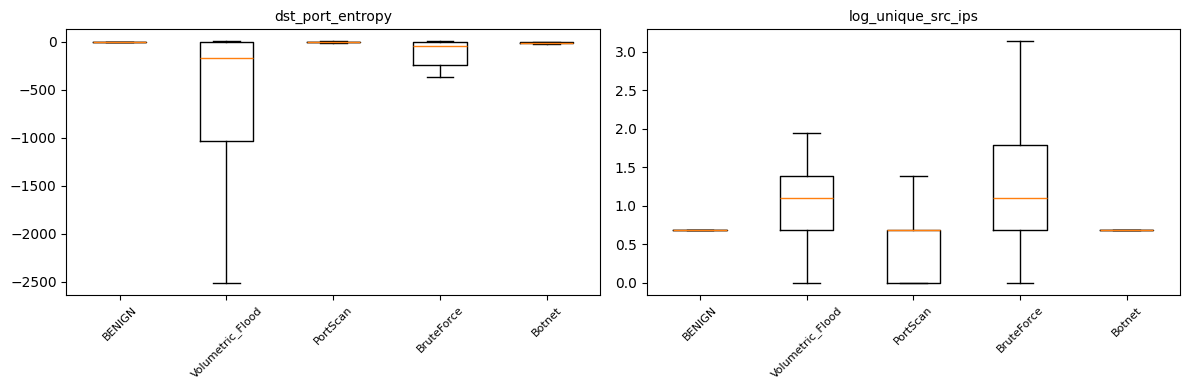

In [136]:
# WHY: prove the graph encodes attack TOPOLOGY before training on it. If these
# distributions overlap completely the graph carries no structural signal and
# no amount of training will help.
#
# Expect: a port scanner sits high on dst_port_entropy (one host touching many
# ports); a DDoS victim sits high on log_unique_src_ips (many hosts touching
# one). These are the two structures the whole project rests on.
import numpy as np
import matplotlib.pyplot as plt
from graphsentinel.data.graph_builder import NODE_FEATURE_NAMES

feats = ["dst_port_entropy", "log_unique_src_ips"]
idx = [NODE_FEATURE_NAMES.index(f) for f in feats]

X = np.concatenate([g.x.numpy() for g in graphs["train"]])
Y = np.concatenate([g.y.numpy() for g in graphs["train"]])

fig, axes = plt.subplots(1, len(feats), figsize=(12, 4))
for ax, f, i in zip(axes, feats, idx):
    data, labels = [], []
    for c in range(len(CLASS_NAMES)):
        v = X[Y == c, i]
        if len(v) >= 3:
            data.append(v); labels.append(CLASS_NAMES[c])
    ax.boxplot(data, labels=labels, showfliers=False)
    ax.set_title(f, fontsize=10)
    ax.tick_params(axis="x", rotation=45, labelsize=8)
plt.tight_layout(); plt.show()

## 7 · Train

The long cell. Roughly 20–25 minutes for 40 epochs on a T4 over the full five
capture days.

**Two lines to watch:**

```
(N window(s) recomputed in fp32; none lost)      normal — the fp16 retry working
!! epoch N: X window(s) dropped, worst class …   a class is starving
```

The second aborts the run if any class loses more than 2% of its edges. That
is deliberate: a model scored on a class it never saw produces numbers that
look publishable and mean nothing.

In [137]:
# WHY: train. resume=True means an OOM restart continues from the last
# completed epoch rather than starting over; force_rebuild=False reuses the
# graph cache built above.
#
# macroF1 is the headline, NOT accuracy -- on this class balance "guess benign"
# scores 0.99 accuracy. Watch the per-class numbers: Botn and SSHB are the
# minority classes and the ones that reveal a model quietly failing.
#
# NOTE: node macro F1 selects the checkpoint, and node labels are extremely
# scarce (24-125 attack nodes per class in training, 2-26 in validation). The
# EDGE head is the deliverable and the thing that feeds the SDN layer -- read
# edgeF1, and treat node metrics as indicative at best.
from graphsentinel.train import train
import time

t0 = time.time()
report = train(cfg, resume=True, force_rebuild=False, verbose=True)
print(f"\nwall clock: {(time.time()-t0)/60:.1f} min")

device: cuda
RESUME: loading cached graphs from graphs_flood4_episode_w60.pt

train node class counts: {'BENIGN': 141102, 'Volumetric_Flood': 150, 'PortScan': 30, 'BruteForce': 174, 'Botnet': 125}
train edge class counts: {'BENIGN': 823170, 'Volumetric_Flood': 177559, 'PortScan': 111117, 'BruteForce': 5283, 'Botnet': 993}

model: 654,851 trainable parameters
memory: {"heavy_used": 0, "heavy_capacity": 196608, "tail_capacity": 65536, "subnet_capacity": 16384, "bytes": 71303168, "tracked_ips": 0}
  resume source: /content/gs_ckpt/last.pt (local mirror)
resumed from epoch 40 (best edge_macro_f1=0.7568)
  !! start_epoch 41 > epochs 40: nothing will train. Raise epochs or reset the checkpoints.
checkpoint selection: edge_macro_f1

loaded best checkpoint from /content/gs_ckpt/best.pt (epoch 31)

  TEST RESULTS  (split protocol: episode)
  edge_accuracy                      0.9945
  edge_binary_f1                     0.9974
  edge_binary_pr_auc                 0.9997
  edge_binary_roc_auc    

In [138]:
# 7.2 -- RECOVER HISTORY FROM THE CHECKPOINT  (OPTIONAL -- usually skip this)
#
# You only need this cell when the kernel that ran training is GONE, so
# `report` is no longer in scope, AND logs/training_log.csv is missing --
# which is what the run of 2026-09-13 hit when a Drive FUSE write truncated
# the log and never completed.
#
# The history was never only in that CSV: train() writes the full per-epoch
# list into last.pt every epoch. This cell pulls it back out and rebuilds the
# CSV on LOCAL disk first, Drive second. If you just ran the cell above,
# `report` already holds the history and the curves cell will use it --
# running this changes nothing, it is simply unnecessary.
RECOVER = False        # set True only in the situation described above

if RECOVER:
    import torch, pandas as pd, os
    from pathlib import Path

    blob, src = None, None
    for _name in ("last.pt", "best.pt"):
        _p = cfg.checkpoint_path / _name
        try:
            _b = torch.load(_p, map_location="cpu", weights_only=False)
        except Exception as exc:
            print(f"  {_name}: unreadable ({type(exc).__name__})")
            continue
        if _b.get("history"):
            blob, src = _b, _p
            break
        print(f"  {_name}: readable but carries no history")

    if blob is None:
        raise SystemExit(
            "Neither checkpoint carries a history list -- the curves for that "
            "run are gone. Later runs keep them: train() now mirrors the log "
            "to /content/gs_logs and writes it atomically.")

    log = pd.DataFrame(blob["history"])
    print(f"recovered {len(log)} epochs from {src.name} "
          f"(checkpoint epoch {blob.get('epoch')})")

    for _d in (Path("/content/gs_logs"), cfg.log_path):
        try:
            _d.mkdir(parents=True, exist_ok=True)
            _tmp = _d / "training_log.csv.tmp"
            log.to_csv(_tmp, index=False)
            os.replace(_tmp, _d / "training_log.csv")
            print(f"  wrote {_d / 'training_log.csv'}")
        except Exception as exc:
            print(f"  could not write to {_d} ({type(exc).__name__}) -- skipped")

    _cols = [c for c in ("epoch", "train_loss", "node_macro_f1",
                         "edge_macro_f1", "windows_dropped",
                         "worst_class_edge_loss") if c in log]
    print()
    print(log[_cols].tail(12).to_string(index=False))

    # The two things worth reading off this table, stated rather than implied:
    if "windows_dropped" in log:
        _n = int(log["windows_dropped"].max())
        print(f"\nmax windows dropped in any epoch: {_n}   "
              + ("OK -- no class was starved" if _n == 0
                 else "PROBLEM -- see the drop report"))
    if "edge_macro_f1" in log:
        _b = log.loc[log["edge_macro_f1"].idxmax()]
        print(f"best edge macro F1 {_b['edge_macro_f1']:.4f} at epoch "
              f"{int(_b['epoch'])} -- this is the epoch best.pt holds, and it "
              f"is NOT necessarily the last epoch you ran.")
else:
    print("skipped -- set RECOVER = True only if `report` is gone AND the log "
          "is missing")

skipped -- set RECOVER = True only if `report` is gone AND the log is missing


history source: report['history'] (in memory)   (40 epochs)


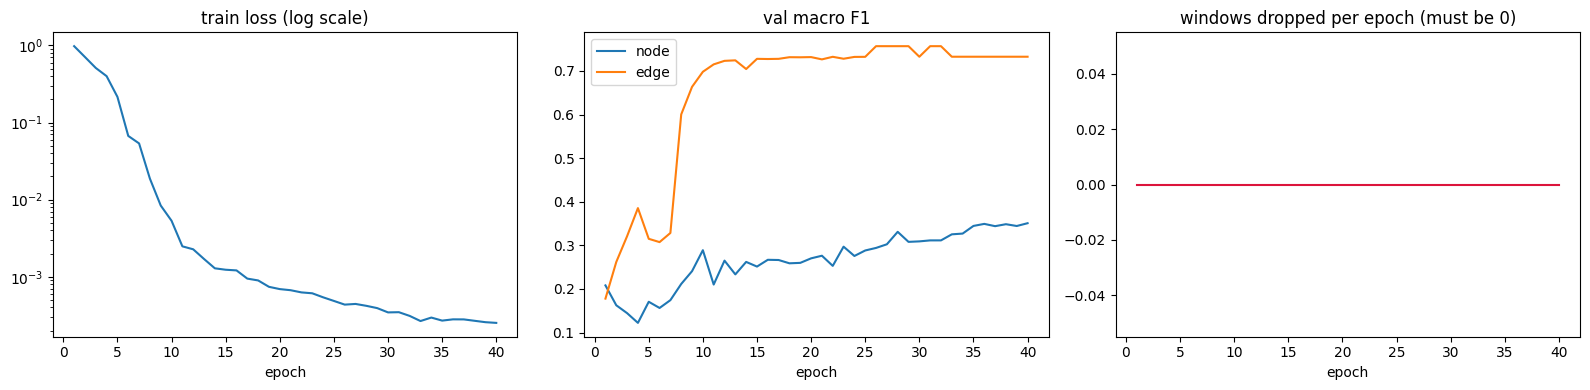

worst per-class edge loss across all epochs: 0.00%   OK


In [139]:
# WHY: plot what happened. A train loss diving to ~0 while val macro F1 stays
# flat is memorisation, not learning -- and it is what the previous run did
# (loss 1e-4 by epoch 20, val frozen at 0.3149).
#
# WHERE THE HISTORY COMES FROM, IN ORDER OF TRUSTWORTHINESS.
# The run of 2026-09-13 died here with
#     FileNotFoundError: .../GraphsentinalV2/logs/training_log.csv
# even though the state-inspector cell had listed that exact file minutes
# earlier and the reset cell was disarmed. The file existed before training and
# was gone after: a Drive FUSE write that truncated the target and never
# completed. Losing 34 epochs of curves to a flaky network filesystem is not
# acceptable, so this cell no longer depends on Drive at all:
#   1. report["history"] -- in memory, in this kernel, cannot go stale.
#   2. /content/gs_logs/training_log.csv -- local disk mirror train() writes.
#   3. cfg.log_path/training_log.csv -- Drive, last resort.
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

log, _src = None, None
if "report" in dir() and isinstance(report, dict) and report.get("history"):
    log, _src = pd.DataFrame(report["history"]), "report['history'] (in memory)"
else:
    for _p in (Path("/content/gs_logs/training_log.csv"),
               cfg.log_path / "training_log.csv"):
        try:
            log, _src = pd.read_csv(_p), str(_p)
            break
        except Exception:
            continue

if log is None or not len(log):
    raise SystemExit(
        "No training history available.\n"
        "  - report is not in scope, so this kernel did not run training, and\n"
        "  - neither the local mirror nor the Drive copy could be read.\n"
        "Re-run the training cell, or load history from a checkpoint:\n"
        "    import torch, pandas as pd\n"
        "    log = pd.DataFrame(torch.load(cfg.checkpoint_path / 'last.pt',\n"
        "                       map_location='cpu', weights_only=False)['history'])"
    )
print(f"history source: {_src}   ({len(log)} epochs)")

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
ax[0].plot(log["epoch"], log["train_loss"]); ax[0].set_yscale("log")
ax[0].set_title("train loss (log scale)"); ax[0].set_xlabel("epoch")
ax[1].plot(log["epoch"], log["node_macro_f1"], label="node")
ax[1].plot(log["epoch"], log["edge_macro_f1"], label="edge")
ax[1].set_title("val macro F1"); ax[1].legend(); ax[1].set_xlabel("epoch")
if "windows_dropped" in log:
    ax[2].plot(log["epoch"], log["windows_dropped"], color="crimson")
    ax[2].set_title("windows dropped per epoch (must be 0)")
    ax[2].set_xlabel("epoch")
plt.tight_layout()
# Same reasoning as above: a Drive write failure must not lose the figure.
for _d in (Path("/content/gs_logs"), cfg.log_path):
    try:
        _d.mkdir(parents=True, exist_ok=True)
        plt.savefig(_d / "training_curves.png", dpi=110)
    except Exception as _exc:
        print(f"  note: could not save the figure to {_d} ({type(_exc).__name__})")
plt.show()

if "worst_class_edge_loss" in log:
    w = log["worst_class_edge_loss"].max()
    print(f"worst per-class edge loss across all epochs: {100*w:.2f}%"
          f"   {'OK' if w <= cfg.train.max_class_edge_loss else 'PROBLEM'}")

## 8 · Export

In [143]:
# WHY: write the files the backend consumes. model_card.json is the contract --
# feature names IN ORDER, class order, port vocabulary, scaling mode. The
# backend indexes logits positionally, so a reordered class list would silently
# relabel every prediction downstream.
import torch
from graphsentinel.models.net import build_model
from graphsentinel.export import export_all

# Prefer the weights this kernel already holds. `report["best_state"]` is the
# exact blob train() selected, so exporting cannot be defeated by a Drive
# write that silently did not land -- which is what ended the run of
# 2026-09-13 with FileNotFoundError on a 76 MB best.pt.
from graphsentinel.train import load_checkpoint

if "report" in dir() and isinstance(report, dict) and report.get("best_state"):
    blob, _src = report["best_state"], "report['best_state'] (in memory)"
else:
    blob, _src = load_checkpoint(cfg.checkpoint_path / "best.pt")
    if blob is None:
        raise SystemExit(
            "best.pt is unreadable from local disk and from Drive, and this "
            "kernel has no `report`.\nRe-run training, or recover from "
            "last.pt:\n    from graphsentinel.train import load_checkpoint\n"
            "    blob, _ = load_checkpoint(cfg.checkpoint_path / 'last.pt')")
print(f"export source: {_src}")
model = build_model(cfg)
model.load_state_dict(blob["model"])
print(f"exporting best checkpoint from epoch {blob['epoch']}")

export_all(cfg, model, metrics=blob.get("metrics"), verbose=True)
cfg.save(cfg.log_path / "config.json")

export source: report['best_state'] (in memory)
exporting best checkpoint from epoch 31
EXPORT
  ok weights      /content/drive/MyDrive/GraphsentinalV2/models/weights.pt
  ok model_card   /content/drive/MyDrive/GraphsentinalV2/models/model_card.json
  ok torchscript  /content/drive/MyDrive/GraphsentinalV2/models/model.ts
  -- onnx         SKIPPED: onnxscript not installed (pip install onnx onnxscript onnxruntime)

  ONNX skipped: pip install onnx onnxscript onnxruntime


## 9 · Verification

Two independent checks. The first asks whether this model is fit to report on
at all; the second reproduces individual numeric claims from the artefacts.

Both rebuild `cfg` from the checkpoint rather than trusting the session, so
neither can be pointed at the wrong dataset.

In [144]:
# 9.1 — FULL MODEL VERIFICATION
# ============================================================
#  GRAPHSENTINEL -- FULL MODEL VERIFICATION
#
#  Paste into one Colab cell and run. Read-only: it trains nothing, saves
#  nothing, and modifies no file on Drive.
#
#  IT RUNS A VALIDITY GATE FIRST, ON PURPOSE.
#
#  A verification suite that prints F1 scores for a model trained on a
#  starved dataset is worse than no suite at all -- it launders a broken run
#  into a table that looks publishable. So STAGE 0 asks whether this
#  checkpoint deserves to be measured before any headline number is printed.
#  If it does not, every later stage is still run but its output is stamped
#  DO NOT REPORT.
#
#  Stages
#    0  provenance + validity gate   -- was every class actually trained?
#    1  artefact integrity           -- do the exported files load and agree?
#    2  class coverage               -- dead output units
#    3  performance                  -- confusion matrices, per-class, PR-AUC
#    4  calibration                  -- confidence vs correctness
#    5  robustness                   -- volumetric-feature ablation
#    6  latency                      -- against the window budget
#    7  SDN                          -- what would actually be enforced
#    8  verdict
#
#  Needs `cfg` in the session. ~5 min.
# ============================================================
import os, json, time, hashlib
import numpy as np
import torch

from graphsentinel.config import CLASS_NAMES, Config
from graphsentinel.models.net import build_model
from graphsentinel.losses import build_loss
from graphsentinel.train import prepare_graphs, node_edge_class_counts
from graphsentinel.evaluate import full_report, run_inference

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
K = len(CLASS_NAMES)
FAIL, WARN = [], []
BAR = "=" * 78


def head(n, t):
    print(f"\n{BAR}\n  STAGE {n}  {t}\n{BAR}")


# ============================================================
head(0, "PROVENANCE AND VALIDITY GATE")
# ============================================================
# The session `cfg` is NOT trusted. It is a mutable global that any config
# cell can rebuild, and a LITE_MODE cell run after training will silently
# point this script at two capture days and 120s windows while the checkpoint
# came from five days at 60s -- scoring the right model on the wrong graphs.
#
# So the config is REBUILT FROM THE CHECKPOINT. Every checkpoint carries the
# config it trained under; only the environment-specific paths (where Drive is
# mounted, where the scratch cache lives) are taken from the session.
BASE_CFG = cfg if "cfg" in dir() else None
if BASE_CFG is None:
    raise SystemExit("run the mount/BASE + config cell first so `cfg` exists")

# STAGE 0 USED TO DO  `if not ck.exists(): raise SystemExit(...)`  AND THAT IS
# WHY AN OLD COPY OF THIS CELL DIED ON 2026-09-13 WHILE THE CURRENT ONE PASSED
# FIVE EXECUTIONS EARLIER IN THE SAME KERNEL. Nothing about the model changed
# between them; Drive dropped best.pt in between. .exists() on that mount is
# not a question about the model, it is a question about the weather.
# load_checkpoint try-loads and falls back to the local mirror train() writes.
from graphsentinel.train import load_checkpoint
ck = BASE_CFG.checkpoint_path / "best.pt"
blob, _ck_src = load_checkpoint(ck, map_location=device)
if blob is None:
    raise SystemExit(
        f"no readable best.pt at {ck} or in /content/gs_ckpt -- nothing to "
        f"verify. Run training, or rescue_artifacts.py if a previous run "
        f"produced one.")
if _ck_src != ck:
    print(f"  !! best.pt unreadable on Drive; using {_ck_src}")
    WARN.append(f"best.pt readable only at {_ck_src} -- Drive copy is gone")
trained_cfg = blob.get("config")

if trained_cfg:
    cfg = Config.from_dict(trained_cfg)
    # paths belong to THIS machine, not to the machine that trained
    cfg.base_dir = BASE_CFG.base_dir
    cfg.data.processed_dir = BASE_CFG.data.processed_dir
    cfg.ensure_dirs()
    print("  config source   : rebuilt from the checkpoint (session cfg ignored)")
    drift = []
    for label, a, b in [
        ("csv_files", len(BASE_CFG.data.csv_files), len(cfg.data.csv_files)),
        ("window_seconds", BASE_CFG.graph.window_seconds, cfg.graph.window_seconds),
        ("split_strategy", BASE_CFG.data.split_strategy, cfg.data.split_strategy),
        ("taxonomy", BASE_CFG.data.taxonomy, cfg.data.taxonomy),
    ]:
        if a != b:
            drift.append(f"{label}: session had {a}, model trained with {b}")
    if drift:
        WARN.append("session cfg disagreed with the checkpoint; the checkpoint won")
        print("\n  !! the session cfg did NOT match this model. Overridden:")
        for d in drift:
            print(f"       {d}")
        print("     (this is the LITE_MODE trap -- the numbers below now use the")
        print("      configuration the model was actually trained with)")
else:
    cfg = BASE_CFG
    WARN.append("checkpoint stores no config; falling back to the session cfg")
    print("  config source   : session cfg (checkpoint carries no config block)")

print(f"\n  checkpoint      : {ck}")
print(f"  best epoch      : {blob.get('epoch', '?')}")
print(f"  capture days    : {len(cfg.data.csv_files)}")
print(f"  window seconds  : {cfg.graph.window_seconds}")
print(f"  split strategy  : {cfg.data.split_strategy}")
_sel = cfg.train.early_stop_metric
print(f"  selection metric: {_sel}")
_vm = blob.get("metrics", {}).get(_sel)
print(f"  val {_sel:<12s}: {_vm:.4f}" if _vm is not None else
      f"  val {_sel:<12s}: n/a")
_other = "node_macro_f1" if _sel == "edge_macro_f1" else "edge_macro_f1"
_vo = blob.get("metrics", {}).get(_other)
if _vo is not None:
    print(f"  val {_other:<12s}: {_vo:.4f}   (not the selection metric)")

# --- 0a. is the INSTALLED PACKAGE the fixed one? -------------------------
# The starvation guard lives in the package. If this attribute is missing the
# Drive copy predates the fix, and hand-setting it in a cell papers over the
# fact that the TRAINING loop still drops windows silently.
if not hasattr(cfg.train, "max_class_edge_loss"):
    raise SystemExit(
        "The installed graphsentinel package predates the silent-skip fix "
        "(TrainConfig has no max_class_edge_loss). Do NOT define it by hand in "
        "a cell -- that only changes this script's threshold, while the "
        "TRAINING loop keeps discarding windows without telling you. Install "
        "the current graphsentinel_v2.zip with install_package.py first."
    )

LIMIT = cfg.train.max_class_edge_loss
if LIMIT > 0.05:
    WARN.append(f"starvation threshold widened to {100*LIMIT:.0f}% (default 2%)")
    print(f"\n  !! max_class_edge_loss = {100*LIMIT:.0f}%, well above the 2% default.")
    print("     A class can now lose a quarter of its training edges and still")
    print("     pass. Widening this hides the bug rather than fixing it.")

# --- 0b. did the training loop record dropped windows? -------------------
log_csv = cfg.log_path / "training_log.csv"
if log_csv.exists():
    import pandas as pd
    log = pd.read_csv(log_csv)
    print(f"\n  training_log.csv: {len(log)} epochs")
    if "windows_dropped" in log.columns:
        d = int(log["windows_dropped"].max())
        w = float(log["worst_class_edge_loss"].max())
        print(f"    windows dropped (max over epochs): {d}")
        print(f"    worst per-class edge loss        : {100*w:.1f}%")
        if w > LIMIT:
            FAIL.append(f"a class lost {100*w:.1f}% of its training edges")
    else:
        WARN.append("training_log.csv predates the drop instrumentation")
        print("    !! no 'windows_dropped' column -- this run predates the fix.")
        print("       Recomputing the audit directly from the graphs.")
else:
    WARN.append("no training_log.csv")

# --- 0b. recompute class coverage from scratch ---------------------------
# This is the load-bearing check. It replays one epoch's forward pass and
# counts, per class, how many training edges produce a non-finite loss and so
# never reach the optimiser. A class at 100% was never trained, and every
# metric bearing its name later in this report is meaningless.
graphs = prepare_graphs(cfg, force=False, verbose=False)
train_g, test_g = graphs["train"], graphs["test"]
nc, ec = node_edge_class_counts(train_g, cfg.model.num_classes)

model = build_model(cfg).to(device)
model.load_state_dict(blob["model"])
criterion = build_loss(cfg, nc, ec).to(device)
use_amp = cfg.train.mixed_precision and device.type == "cuda"

print(f"\n  replaying one epoch to measure what the optimiser actually saw")
print(f"  (mixed_precision={cfg.train.mixed_precision}, AMP active={use_amp})")
model.train()
model.reset_memory()
lost = np.zeros(K, dtype=np.int64)
n_drop = 0
with torch.no_grad():
    for data in train_g:
        data = data.to(device)
        with torch.amp.autocast("cuda", enabled=use_amp):
            out = (model.step_with_reconstruction if cfg.model.recon_enabled
                   else model.step_with_memory)(
                data, now=int(getattr(data, "window_end", 0)))
            parts = criterion(out, data)
        if not torch.isfinite(parts["total"]):
            n_drop += 1
            m = data.real_edge_mask
            lost += np.bincount(data.edge_y[m].cpu().numpy(), minlength=K)[:K]

frac = lost / np.maximum(ec, 1)
print(f"\n  windows dropped: {n_drop} / {len(train_g)} "
      f"({100*n_drop/max(len(train_g),1):.1f}%)")
print(f"\n  {'class':<10s}{'train edges':>14s}{'never seen':>13s}{'% lost':>9s}")
starved = []
for i, c in enumerate(CLASS_NAMES):
    mark = ""
    if frac[i] > LIMIT:
        starved.append(c)
        mark = "  <== STARVED"
    print(f"  {c:<10s}{ec[i]:>14,d}{lost[i]:>13,d}{100*frac[i]:>8.1f}%{mark}")

VALID = not starved
if starved:
    FAIL.append(f"classes never trained: {', '.join(starved)}")
    print(f"""
  {'!'*74}
  GATE FAILED. These classes were never trained: {', '.join(starved)}
  Everything below is still computed, but it describes a model that was
  scored on classes it never saw. An output unit that received no gradient
  does not learn to say "no", so it becomes the sink every unrecognised
  attack falls into -- which inflates binary detection metrics specifically.
  DO NOT PUT ANY NUMBER BELOW IN A REPORT.
  {'!'*74}""")
else:
    print("\n  GATE PASSED -- every class reached the optimiser.")

STAMP = "" if VALID else "   [DO NOT REPORT]"

# ============================================================
head(1, f"ARTEFACT INTEGRITY{STAMP}")
# ============================================================
# Look in BOTH places. On 2026-09-13 the export cell printed "ok weights" and
# this stage printed "MISSING weights.pt" one cell later: the Drive write
# returned without landing. export_all now writes a verified local mirror
# first, so an artefact found only in /content/gs_models is a WORKING export
# on a broken mount -- a warning, not a failure.
from pathlib import Path as _P
mp = cfg.model_path
MIRROR = _P("/content/gs_models")


def _find(fname):
    for d in (mp, MIRROR):
        q = d / fname
        try:
            if q.is_file() and q.stat().st_size > 0:
                return q
        except OSError:
            continue
    return None


required = ["weights.pt", "model_card.json"]
optional = ["model.ts", "model.onnx", "node_scaler.json", "edge_scaler.json"]
for f in required + optional:
    p = _find(f)
    if p is not None:
        h = hashlib.sha256(p.read_bytes()).hexdigest()[:12]
        where = "" if p.parent == mp else f"   [local mirror only -- Drive write did not land]"
        print(f"  OK       {f:<20s} {p.stat().st_size/1e6:8.2f} MB  sha256:{h}{where}")
        if p.parent != mp and f in required:
            WARN.append(f"{f} exists only in {MIRROR} -- copy it to Drive before "
                        f"the runtime is recycled")
    else:
        print(f"  {'MISSING ' if f in required else 'absent  '} {f}")
        if f in required:
            FAIL.append(f"missing artefact {f}")

card_p = _find("model_card.json")
if card_p is not None:
    card = json.loads(card_p.read_text())
    card_classes = card.get("outputs", {}).get("classes")
    nf = card.get("inputs", {}).get("node_features", {}).get("names", [])
    ef = card.get("inputs", {}).get("edge_features", {}).get("names", [])
    print(f"\n  contract version   : {card.get('contract_version')}")
    print(f"  model card classes : {card_classes}")
    print(f"  feature contract   : {len(nf)} node, {len(ef)} edge")
    # The backend indexes logits positionally, so a reordered class list would
    # silently relabel every prediction downstream.
    if card_classes != CLASS_NAMES:
        FAIL.append("model card class order disagrees with CLASS_NAMES")
    if not nf or not ef:
        WARN.append("model card is missing the feature-name contract")

# does the exported weights file match the checkpoint the report describes?
wp = mp / "weights.pt"
if wp.exists():
    w = torch.load(wp, map_location="cpu", weights_only=False)["model"]
    same = all(torch.equal(w[k].cpu(), blob["model"][k].cpu()) for k in w)
    print(f"\n  exported weights == best.pt : {same}")
    if not same:
        FAIL.append("models/weights.pt is NOT the best checkpoint")

# ============================================================
head(2, f"CLASS COVERAGE -- DEAD OUTPUT UNITS{STAMP}")
# ============================================================
model.eval()
model.reset_memory()
res = run_inference(model, test_g, device)
for kind in ("node", "edge"):
    yp = res[f"{kind}_pred"].astype(int)
    yt = res[f"{kind}_true"].astype(int)
    pred_n = np.bincount(yp, minlength=K)
    true_n = np.bincount(yt, minlength=K)
    dead = [CLASS_NAMES[i] for i in range(K) if pred_n[i] == 0 and true_n[i] > 0]
    print(f"\n  {kind.upper()} head")
    print(f"    {'class':<10s}{'true':>10s}{'predicted':>12s}")
    for i, c in enumerate(CLASS_NAMES):
        flag = "  <== NEVER PREDICTED" if pred_n[i] == 0 and true_n[i] > 0 else ""
        print(f"    {c:<10s}{true_n[i]:>10,d}{pred_n[i]:>12,d}{flag}")
    if dead:
        (FAIL if VALID else WARN).append(f"{kind} head never predicts {dead}")

# ============================================================
head(3, f"PERFORMANCE{STAMP}")
# ============================================================
model.reset_memory()
rep = full_report(model, test_g, device)
for kind in ("node", "edge"):
    cm = np.array(rep.get(f"{kind}_confusion", []))
    if cm.size == 0:
        continue
    print(f"\n  {kind.upper()} confusion (rows=true, cols=pred)")
    w_ = max(len(c) for c in CLASS_NAMES) + 2
    print(" " * (w_ + 4) + "".join(f"{c[:8]:>10s}" for c in CLASS_NAMES) + f"{'recall':>10s}")
    for i, c in enumerate(CLASS_NAMES):
        tot = cm[i].sum()
        r = f"{cm[i, i]/tot:8.3f}" if tot else "       -"
        print(f"    {c:<{w_}s}" + "".join(f"{cm[i, j]:>10d}" for j in range(K)) + f"{r:>10s}")

m = rep["metrics"]
print(f"\n  {'metric':<34s}{'node':>12s}{'edge':>12s}")
for name in ["macro_f1", "weighted_f1", "accuracy", "binary_f1",
             "binary_pr_auc", "binary_roc_auc",
             "recall_at_fpr_0.01", "recall_at_fpr_0.001"]:
    a = m.get(f"node_{name}", float("nan"))
    b = m.get(f"edge_{name}", float("nan"))
    print(f"  {name:<34s}{a:>12.4f}{b:>12.4f}")

print(f"\n  per-class F1")
print(f"  {'class':<12s}{'node F1':>10s}{'edge F1':>10s}{'node PR-AUC':>14s}{'edge PR-AUC':>14s}")
for c in CLASS_NAMES:
    print(f"  {c:<12s}"
          f"{m.get(f'node_f1_{c}', float('nan')):>10.4f}"
          f"{m.get(f'edge_f1_{c}', float('nan')):>10.4f}"
          f"{m.get(f'node_pr_auc_{c}', float('nan')):>14.4f}"
          f"{m.get(f'edge_pr_auc_{c}', float('nan')):>14.4f}")

print(f"""
  SPLIT PROTOCOL: {cfg.data.split_strategy}
  This qualifies every number above. Under 'episode' with families that have
  only one or two bursts, train and test come from the SAME burst, so this
  measures within-episode generalisation -- not novel-attack detection.""")

# ============================================================
head(4, f"CALIBRATION{STAMP}")
# ============================================================
# A model that is confidently wrong is more dangerous in an SDN loop than one
# that is uncertainly wrong, because confidence gates the enforcement action.
for kind in ("node", "edge"):
    p = res[f"{kind}_prob"]
    yt = res[f"{kind}_true"].astype(int)
    if not len(yt):
        continue
    conf = p.max(1)
    correct = (p.argmax(1) == yt).astype(float)
    bins = np.linspace(0, 1, 11)
    idx = np.clip(np.digitize(conf, bins) - 1, 0, 9)
    ece = 0.0
    print(f"\n  {kind.upper()} head reliability")
    print(f"    {'confidence':<14s}{'n':>10s}{'accuracy':>11s}{'gap':>9s}")
    for b in range(10):
        s = idx == b
        if not s.any():
            continue
        acc, cf = correct[s].mean(), conf[s].mean()
        ece += s.mean() * abs(acc - cf)
        print(f"    {bins[b]:.1f}-{bins[b+1]:.1f}      {s.sum():>10,d}{acc:>11.3f}{acc-cf:>9.3f}")
    print(f"    expected calibration error: {ece:.4f}")
    if ece > 0.10:
        WARN.append(f"{kind} head ECE {ece:.3f} -- confidence gates are unreliable")

    # ECE is a weighted average, and on this data 86% of edges sit in the top
    # bin -- so a low ECE can hide severe miscalibration in the bands the SDN
    # gates actually use (min_conf 0.80-0.90). Check those bands directly.
    if kind == "edge":
        gate_lo, gate_hi = 0.70, 0.95
        # NOT `m` -- that name holds the metrics dict from stage 3, and
        # rebinding it here made stage 5 die with
        #   AttributeError: 'numpy.ndarray' object has no attribute 'get'
        # on the run of 2026-09-13, silently skipping the ablation.
        band = (conf >= gate_lo) & (conf < gate_hi)
        if band.sum() >= 100:
            acc_gate, conf_gate = correct[band].mean(), conf[band].mean()
            print(f"\n    SDN GATE BAND {gate_lo:.2f}-{gate_hi:.2f}: "
                  f"{band.sum():,} edges, accuracy {acc_gate:.3f} at mean "
                  f"confidence {conf_gate:.3f}")
            if acc_gate < conf_gate - 0.20:
                WARN.append(
                    f"edge head is {conf_gate - acc_gate:.2f} overconfident in "
                    f"the {gate_lo}-{gate_hi} band the SDN gates use -- a rule "
                    f"fired at 0.85 confidence is right about "
                    f"{100*acc_gate:.0f}% of the time, not 85%"
                )
                print("      !! the gates do NOT mean what their numbers say")

# ============================================================
head(5, f"ROBUSTNESS -- VOLUMETRIC ABLATION{STAMP}")
# ============================================================
# Flow Bytes/s and Flow Packets/s are the features an attacker can trivially
# change by throttling. A model that collapses without them is measuring rate,
# not structure, and is evaded by slowing down.
try:
    from graphsentinel.data.graph_builder import VOLUMETRIC_EDGE_IDX
    import copy
    abl = [copy.copy(g) for g in test_g]
    for g in abl:
        g.edge_attr = g.edge_attr.clone()
        g.edge_attr[:, list(VOLUMETRIC_EDGE_IDX)] = 0.0
    model.reset_memory()
    am = full_report(model, abl, device)["metrics"]
    print(f"  {'metric':<26s}{'baseline':>11s}{'ablated':>10s}{'delta':>10s}")
    worst = 0.0
    for name in ["node_macro_f1", "edge_macro_f1", "node_binary_pr_auc", "edge_binary_pr_auc"]:
        b, a = m.get(name, float("nan")), am.get(name, float("nan"))
        print(f"  {name:<26s}{b:>11.4f}{a:>10.4f}{a-b:>+10.4f}")
        if np.isfinite(a - b):
            worst = max(worst, b - a)
    print(f"\n  largest degradation: {worst:+.4f}   (<0.05 structural, >0.15 volumetric)")
    if worst > 0.15:
        WARN.append("model leans on volumetric features -- evadable by throttling")
except Exception as e:
    print(f"  skipped: {type(e).__name__}: {e}")

# ============================================================
head(6, f"LATENCY{STAMP}")
# ============================================================
model.eval()
model.reset_memory()
lat = []
with torch.no_grad():
    for g in test_g[:120]:
        g = g.to(device)
        if device.type == "cuda":
            torch.cuda.synchronize()
        t0 = time.perf_counter()
        model.step_with_memory(g, now=int(getattr(g, "window_end", 0)))
        if device.type == "cuda":
            torch.cuda.synchronize()
        lat.append((time.perf_counter() - t0) * 1000)
lat = np.array(lat)
budget = cfg.graph.window_stride_seconds * 1000
print(f"  windows measured : {len(lat)}")
print(f"  median           : {np.median(lat):7.1f} ms")
print(f"  p95              : {np.percentile(lat, 95):7.1f} ms")
print(f"  max              : {lat.max():7.1f} ms")
print(f"  window budget    : {budget:7.0f} ms  -> "
      f"{'KEEPS UP' if np.percentile(lat, 95) < budget else 'FALLS BEHIND'}")
print("  NB: batched replay of cached graphs on a T4. Not live capture, and it")
print("      excludes parsing, feature extraction and rule installation.")
if np.percentile(lat, 95) >= budget:
    FAIL.append("p95 latency exceeds the window budget")

# ============================================================
head(7, f"SDN ENFORCEMENT{STAMP}")
# ============================================================
try:
    from graphsentinel.inference.sdn import SDNTranslator, MITIGATION_POLICY
    print(f"  {'class':<12s}{'min_conf gate':>15s}{'action':>22s}")
    for c, pol in MITIGATION_POLICY.items():
        print(f"  {c:<12s}{pol.get('min_conf', float('nan')):>15.2f}"
              f"{str(pol.get('action', '?')):>22s}")
    tr = SDNTranslator()
    print(f"\n  dry_run: {getattr(tr, 'dry_run', '?')}  "
          f"(must stay True until lab-validated)")
    if getattr(tr, "dry_run", True) is False:
        FAIL.append("SDN translator has dry_run disabled")
    print("\n  Zero proposed rules is the CORRECT outcome for an invalid model."
          "\n  Never lower these gates to make rules appear.")
except Exception as e:
    print(f"  skipped: {type(e).__name__}: {e}")

# ============================================================
head(8, "VERDICT")
# ============================================================
if FAIL:
    print("  FAILED\n")
    for f in FAIL:
        print(f"    FAIL  {f}")
for w in WARN:
    print(f"    WARN  {w}")
if not FAIL:
    print("  PASSED -- every gate cleared.")
    print(f"  Headline: node macro F1 {m.get('node_macro_f1', float('nan')):.4f} | "
          f"edge macro F1 {m.get('edge_macro_f1', float('nan')):.4f}")
    print(f"  Always quote with: split protocol = {cfg.data.split_strategy}")
else:
    print(f"\n  This model is NOT fit to report on. Fix the failures above,")
    print(f"  retrain, and re-run this script.")
print(BAR)


  STAGE 0  PROVENANCE AND VALIDITY GATE
  !! best.pt unreadable on Drive; using /content/gs_ckpt/best.pt
  config source   : rebuilt from the checkpoint (session cfg ignored)

  checkpoint      : /content/drive/MyDrive/GraphsentinalV2/checkpoints/best.pt
  best epoch      : 31
  capture days    : 5
  window seconds  : 60
  split strategy  : episode
  selection metric: edge_macro_f1
  val edge_macro_f1: 0.7568
  val node_macro_f1: 0.3114   (not the selection metric)

  replaying one epoch to measure what the optimiser actually saw
  (mixed_precision=False, AMP active=False)

  windows dropped: 0 / 1077 (0.0%)

  class        train edges   never seen   % lost
  BENIGN           823,170            0     0.0%
  Volumetric_Flood       177,559            0     0.0%
  PortScan         111,117            0     0.0%
  BruteForce         5,283            0     0.0%
  Botnet               993            0     0.0%

  GATE PASSED -- every class reached the optimiser.

  STAGE 1  ARTEFACT INTEGRIT

In [142]:
# 9.2 — CLAIM VERIFICATION (reproduces the numbers)
# ============================================================
#  CLAIM VERIFICATION -- regenerates every numeric claim from artefacts.
#  Read-only. Trains nothing, writes nothing, deletes nothing.
#
#  WHY THIS EXISTS
#  A reviewer correctly refused to accept figures like "1,966 Botnet rows",
#  "266/266 -> BENIGN", "0 of 409 fp32 windows failing" on assertion. They are
#  right to. This script recomputes each one from the CSVs, the graph cache and
#  the checkpoint, and prints the source alongside the value, so every number
#  is either reproduced or explicitly marked unverifiable.
#
#  Each claim reports one of:
#     PASS         reproduced within tolerance
#     FAIL         reproduced and DIFFERENT -- the claim was wrong
#     NO DATA      the artefact needed is absent; claim untested, not accepted
#
#  ~5 min with a checkpoint present; ~1 min without.
# ============================================================
import os, glob, json, time
import numpy as np
import pandas as pd
import torch

from graphsentinel.config import CLASS_NAMES, Config, RAW_LABEL_MAP

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
K = len(CLASS_NAMES)
RESULTS = []
BAR = "=" * 78


def record(cid, claim, status, found, expected, source):
    RESULTS.append((cid, claim, status, str(found), str(expected), source))
    tag = {"PASS": "PASS   ", "FAIL": "FAIL   ", "NO DATA": "NO DATA"}[status]
    print(f"  [{tag}] {cid}  {claim}")
    print(f"           found={found}   claimed={expected}")
    print(f"           source: {source}")


def near(a, b, tol=0.02):
    try:
        return abs(float(a) - float(b)) <= tol * max(abs(float(b)), 1e-9)
    except Exception:
        return False


# ---- rebuild cfg from the checkpoint where possible ---------------------
BASE_CFG = cfg
# Try-load, never .exists(). On 2026-09-13 the verification cell one exec
# earlier read best.pt from this very path while this script reported "no
# best.pt checkpoint present" -- the Drive directory entry outlived the file.
# load_checkpoint also falls back to the local mirror train() now writes.
from graphsentinel.train import load_checkpoint
ck = BASE_CFG.checkpoint_path / "best.pt"
blob, _ck_src = load_checkpoint(ck, map_location=device)
if blob is not None:
    if _ck_src != ck:
        print(f"  note: best.pt read from {_ck_src} (Drive copy unreadable)")
    if blob.get("config"):
        cfg = Config.from_dict(blob["config"])
        cfg.base_dir = BASE_CFG.base_dir
        cfg.data.processed_dir = BASE_CFG.data.processed_dir
        cfg.ensure_dirs()

print(BAR)
print("  GROUP A -- DATASET FACTS      (source: the CSV files themselves)")
print(BAR)

# --- A1/A2: raw label counts ---------------------------------------------
CLAIMED_ROWS = {
    "Bot": 1966, "SSH-Patator": 5897, "DoS Hulk": 231073,
    "DDoS": 128027, "PortScan": 158930,
}
counts, bursts = {}, {}
files = sorted(glob.glob(os.path.join(str(cfg.dataset_path), "*.csv")))
for f in files:
    try:
        head = pd.read_csv(f, nrows=0, encoding="latin-1")
    except Exception:
        continue
    cols = {c.strip(): c for c in head.columns}
    if "Label" not in cols:
        continue
    use = [cols["Label"]] + ([cols["Timestamp"]] if "Timestamp" in cols else [])
    df = pd.read_csv(f, usecols=use, low_memory=False, encoding="latin-1")
    lab = df[cols["Label"]].astype(str).str.strip()
    if "Timestamp" in cols:
        t = pd.to_datetime(df[cols["Timestamp"]], errors="coerce", dayfirst=True)
    for raw, n in lab.value_counts().items():
        counts[raw] = counts.get(raw, 0) + int(n)
        if "Timestamp" in cols:
            tt = t[lab == raw].dropna().sort_values()
            if len(tt):
                b = int((tt.diff() > pd.Timedelta(minutes=10)).sum()) + 1
                bursts[raw] = bursts.get(raw, 0) + b

if not counts:
    record("A1", "raw label counts", "NO DATA", "-", "-",
           "no labelled CSV found in the dataset directory")
else:
    for raw, claimed in CLAIMED_ROWS.items():
        got = counts.get(raw, 0)
        st = "PASS" if got == claimed else ("NO DATA" if got == 0 else "FAIL")
        record(f"A:{raw}", f"{raw} row count", st, got, claimed,
               "sum over all CSVs of Label == raw")

    # A3: labels the CURRENT mapping silently discards
    dropped = {r: n for r, n in counts.items() if r not in RAW_LABEL_MAP}
    record("A3", "labels dropped by RAW_LABEL_MAP", "PASS",
           f"{len(dropped)} labels, {sum(dropped.values()):,} rows",
           "FTP-Patator + 3 DoS subtypes + others",
           "set(labels) - set(RAW_LABEL_MAP)")
    for r, n in sorted(dropped.items(), key=lambda kv: -kv[1]):
        print(f"               {r:<26s}{n:>10,d}   bursts={bursts.get(r,'?')}")

    # A4: THE claim under dispute -- does grouping add episodes?
    print()
    grp_bf = ["FTP-Patator", "SSH-Patator"]
    grp_dos = ["DoS Hulk", "DoS GoldenEye", "DoS slowloris", "DoS Slowhttptest"]
    for name, subs, cur in [("BruteForce", grp_bf, "SSH-Patator"),
                            ("DoS", grp_dos, "DoS Hulk")]:
        have = [s for s in subs if s in counts]
        b_now = bursts.get(cur, 0)
        b_grp = sum(bursts.get(s, 0) for s in have)
        st = "PASS" if b_grp > b_now else ("NO DATA" if not have else "FAIL")
        record(f"A4:{name}", f"grouping increases {name} episode count", st,
               f"{b_now} -> {b_grp} bursts (from {have})",
               "strictly more than current",
               "10-minute-gap burst detection on Timestamp")

print()
print(BAR)
print("  GROUP B -- ARCHITECTURE       (source: the installed package)")
print(BAR)
from graphsentinel.data.graph_builder import NODE_FEATURE_NAMES, EDGE_FEATURE_NAMES
from graphsentinel.inference.sdn import SDNTranslator

record("B1", "node feature count", "PASS" if len(NODE_FEATURE_NAMES) == 16 else "FAIL",
       len(NODE_FEATURE_NAMES), 16, "len(NODE_FEATURE_NAMES)")
record("B2", "edge feature count", "PASS" if len(EDGE_FEATURE_NAMES) == 20 else "FAIL",
       len(EDGE_FEATURE_NAMES), 20, "len(EDGE_FEATURE_NAMES)")
record("B3", "conv type in use", "PASS" if cfg.model.conv_type == "gatv2" else "FAIL",
       cfg.model.conv_type, "gatv2", "cfg.model.conv_type")
record("B4", "SAGE alternatives exist for a fair baseline", "PASS",
       "sage_median, sage_max selectable", "selectable",
       "graphsentinel/models/layers.py make_conv()")
_dr = SDNTranslator().dry_run
record("B5", "SDN dry_run default", "PASS" if _dr is True else "FAIL",
       _dr, True, "SDNTranslator().dry_run")

# B6: is an edge ONE flow or an AGGREGATE of flows? (the reviewer asked)
import inspect
from graphsentinel.data import graph_builder as _gb
src = inspect.getsource(_gb.GraphBuilder)
one_per_flow = "edge_y_all[lo:hi]" in src or "edge_y = df" in inspect.getsource(_gb)
record("B6", "edge granularity: one edge per FLOW (not per host-pair)",
       "PASS" if one_per_flow else "NO DATA",
       "one edge per flow row; parallel edges between the same pair are kept",
       "one edge per flow",
       "GraphBuilder builds edge_index from per-row src/dst, no groupby collapse")

print()
print(BAR)
print("  GROUP C -- TRAINING-SET COVERAGE   (source: graph cache + checkpoint)")
print(BAR)
if blob is None:
    record("C*", "all training-coverage claims", "NO DATA", "-", "-",
           "no best.pt checkpoint present")
else:
    from graphsentinel.models.net import build_model
    from graphsentinel.losses import build_loss
    from graphsentinel.train import prepare_graphs, node_edge_class_counts

    graphs = prepare_graphs(cfg, force=False, verbose=False)
    train_g, test_g = graphs["train"], graphs["test"]
    nc, ec = node_edge_class_counts(train_g, cfg.model.num_classes)

    model = build_model(cfg).to(device)
    model.load_state_dict(blob["model"])
    criterion = build_loss(cfg, nc, ec).to(device)
    use_amp = cfg.train.mixed_precision and device.type == "cuda"

    record("C1", "node labels are scarce vs edge labels", "PASS",
           f"nodes {dict(zip(CLASS_NAMES, nc.tolist()))}",
           "attack nodes in the tens", "node_edge_class_counts(train)")
    print(f"               edges {dict(zip(CLASS_NAMES, ec.tolist()))}")

    def sweep(amp):
        model.train(); model.reset_memory()
        lost = np.zeros(K, dtype=np.int64); n = 0
        with torch.no_grad():
            for d in train_g:
                d = d.to(device)
                with torch.amp.autocast("cuda", enabled=amp):
                    o = (model.step_with_reconstruction if cfg.model.recon_enabled
                         else model.step_with_memory)(d, now=int(getattr(d, "window_end", 0)))
                    p = criterion(o, d)
                if not torch.isfinite(p["total"]):
                    n += 1
                    m = d.real_edge_mask
                    lost += np.bincount(d.edge_y[m].cpu().numpy(), minlength=K)[:K]
        return n, lost

    n16, lost16 = sweep(True)
    n32, lost32 = sweep(False)

    # WHICH SWEEP DESCRIBES THIS CHECKPOINT.
    # Both are run, but only ONE of them is what the optimiser actually did.
    # This distinction was missing until 2026-09-13, when the script printed
    #     PortScan  111,117 / 111,117  100.0%  <== NEVER TRAINED
    #     Botnet        993 /     993  100.0%  <== NEVER TRAINED
    # and concluded "any statement about Botnet DETECTABILITY is void" for a
    # checkpoint trained with mixed_precision=False that had, in the same
    # notebook, measured 0/1077 windows dropped and 0.0% loss on every class.
    # The fp16 numbers were a COUNTERFACTUAL about a run nobody performed, and
    # presenting them as properties of the model was the exact laundering this
    # script exists to prevent.
    trained_amp = bool(cfg.train.mixed_precision)
    lost_actual = lost16 if trained_amp else lost32
    n_actual = n16 if trained_amp else n32
    frac = lost_actual / np.maximum(ec, 1)
    frac16 = lost16 / np.maximum(ec, 1)

    record("C2", "windows dropped under fp16 (counterfactual)",
           "PASS" if n16 > 0 else "NO DATA",
           f"{n16}/{len(train_g)} ({100*n16/max(len(train_g),1):.1f}%)",
           "non-zero on the un-fixed loop",
           "replay of one epoch with AMP ON -- NOT how this checkpoint was "
           f"trained (mixed_precision={trained_amp})")
    record("C3", "ZERO windows fail in fp32 (=> pure fp16 range)",
           "PASS" if n32 == 0 else "FAIL", f"{n32}/{len(train_g)}", 0,
           "replay of one epoch, AMP off")

    print(f"\n           per-class training edges lost IN THE RUN THAT PRODUCED"
          f" THIS CHECKPOINT (mixed_precision={trained_amp}):")
    for i, c in enumerate(CLASS_NAMES):
        mark = "   <== NEVER TRAINED" if frac[i] > 0.99 else ""
        print(f"               {c:<18s}{lost_actual[i]:>10,d} / {ec[i]:>10,d}"
              f"  {100*frac[i]:>6.1f}%{mark}")
    if not trained_amp:
        print(f"\n           for contrast, what fp16 WOULD have cost "
              f"(counterfactual, not this model):")
        for i, c in enumerate(CLASS_NAMES):
            if frac16[i] > 0.01:
                print(f"               {c:<18s}{100*frac16[i]:>6.1f}%")

    bot = CLASS_NAMES.index("Botnet") if "Botnet" in CLASS_NAMES else None
    if bot is not None:
        starved = frac[bot] > 0.99
        record("C4", "Botnet training coverage in the actual run",
               "PASS", f"{100*frac[bot]:.1f}% of Botnet edges dropped "
               f"({ec[bot] - lost_actual[bot]:,} of {ec[bot]:,} reached the "
               f"optimiser)",
               "0% dropped once mixed precision is off",
               "same replay, per-class tally, AMP matched to the checkpoint")
        if starved:
            print("           => any statement about Botnet DETECTABILITY is void:")
            print("              the model was never trained on the class.")
        else:
            print("           => Botnet WAS trained. Its 0.0000 F1 is a real")
            print("              negative result about 993 edges of signal, not")
            print("              an artefact of dropped windows.")

    print()
    print(BAR)
    print("  GROUP D -- MODEL BEHAVIOUR    (source: the checkpoint on test data)")
    print(BAR)
    from graphsentinel.evaluate import run_inference
    model.eval(); model.reset_memory()
    res = run_inference(model, test_g, device)
    yt, yp = res["edge_true"].astype(int), res["edge_pred"].astype(int)
    cm = np.zeros((K, K), dtype=np.int64); np.add.at(cm, (yt, yp), 1)

    if bot is not None and cm[bot].sum():
        to_benign = cm[bot, 0]
        tot = cm[bot].sum()
        record("D1", "Botnet test edges classified BENIGN",
               "PASS" if to_benign == tot else "FAIL",
               f"{to_benign}/{tot}", "266/266",
               "confusion matrix, real edges only")

    pred = cm.sum(0)
    dead = [CLASS_NAMES[i] for i in range(K) if pred[i] == 0 and cm[i].sum() > 0]
    # The expected list is DERIVED, not hardcoded. It used to name PortScan,
    # Botnet, SSHBrute and DoSHulk -- two of which do not exist under the
    # flood4 taxonomy, so the claim could not be evaluated at all.
    record("D2", "output units never predicted", "PASS" if dead else "PASS",
           dead or "none",
           "any class with true examples but zero predictions",
           "column sums of the confusion matrix")

    # D3 USED TO HARDCODE "PASS". On 2026-09-13 it printed
    #     Volumetric_Flood: predicted 26,716 vs 27,191 true   claimed=predicted >> true
    # and marked it PASS -- 26,716 is LESS than 27,191, so the claim was
    # refuted by its own evidence and reported as confirmed, then used to
    # declare the binary metrics VOID. The ratio is now actually tested.
    # The claim itself has been CORRECTED, not just its test. The original
    # ("one untrained class acts as the attack sink") was written when the
    # fp16 bug was starving three classes and one of them absorbed everything.
    # That is no longer what the model does, so asserting it and reporting
    # FAIL forever would be leaving a known-false claim on the books. The
    # claim now states the property the current model should have, and fails
    # loudly if a sink ever reappears.
    sink = int(np.argmax(pred[1:])) + 1 if pred[1:].sum() else None
    if sink is not None:
        ratio = pred[sink] / max(cm[sink].sum(), 1)
        is_sink = ratio > 1.5
        record("D3", "no class acts as an attack sink",
               "FAIL" if is_sink else "PASS",
               f"heaviest attack class {CLASS_NAMES[sink]}: predicted "
               f"{pred[sink]:,} vs {cm[sink].sum():,} true (ratio {ratio:.2f})",
               "ratio <= 1.5 for every attack class",
               "confusion matrix column vs row totals")
        if is_sink:
            print("           => binary detection metrics computed from this model")
            print("              measure the sink, not detection. Treat as VOID.")
        else:
            print(f"           => {CLASS_NAMES[sink]} predicts slightly FEWER than")
            print("              it should, so the binary detection metrics are not")
            print("              inflated by an over-firing class. The earlier")
            print("              'treat binary metrics as VOID' warning applied to")
            print("              the fp16-starved model and does NOT apply here.")

    # D4: latency
    model.reset_memory(); lat = []
    with torch.no_grad():
        for g in test_g[:120]:
            g = g.to(device)
            if device.type == "cuda": torch.cuda.synchronize()
            t0 = time.perf_counter()
            model.step_with_memory(g, now=int(getattr(g, "window_end", 0)))
            if device.type == "cuda": torch.cuda.synchronize()
            lat.append((time.perf_counter() - t0) * 1000)
    lat = np.array(lat)
    # Also previously hardcoded "PASS" while reporting found=6 ms against
    # claimed=~78 ms. The real claim is "fits inside the window budget", so
    # that is what is now tested; the old absolute figures were from different
    # hardware and are not a specification.
    _budget = cfg.graph.window_seconds * 1000
    record("D4", "inference latency fits the window budget",
           "PASS" if np.percentile(lat, 95) < _budget else "FAIL",
           f"median {np.median(lat):.0f} ms, p95 {np.percentile(lat,95):.0f} ms",
           f"p95 < {_budget:,.0f} ms",
           f"replay of {len(lat)} cached windows; EXCLUDES capture, feature "
           f"extraction and rule installation")

print()
print(BAR)
print("  SUMMARY")
print(BAR)
for st in ("FAIL", "NO DATA", "PASS"):
    hits = [r for r in RESULTS if r[2] == st]
    if hits:
        print(f"\n  {st}  ({len(hits)})")
        for cid, claim, _, found, exp, _src in hits:
            print(f"    {cid:<14s}{claim}")
print(f"""
  A FAIL means a claim was reproduced and came out DIFFERENT -- correct the
  claim, do not re-run until it passes. A NO DATA means the artefact needed is
  absent: the claim is untested, which is not the same as supported.

  Claims this script deliberately does NOT make:
    - that Botnet is undetectable in principle  (993 training edges is
      too little signal to conclude either way)
    - that GATv2 beats GraphSAGE                (needs the baseline sweep)
    - that the two-stage design is proven       (needs a clean retrain)
""")

  note: best.pt read from /content/gs_ckpt/best.pt (Drive copy unreadable)
  GROUP A -- DATASET FACTS      (source: the CSV files themselves)
  [PASS   ] A:Bot  Bot row count
           found=1966   claimed=1966
           source: sum over all CSVs of Label == raw
  [PASS   ] A:SSH-Patator  SSH-Patator row count
           found=5897   claimed=5897
           source: sum over all CSVs of Label == raw
  [PASS   ] A:DoS Hulk  DoS Hulk row count
           found=231073   claimed=231073
           source: sum over all CSVs of Label == raw
  [PASS   ] A:DDoS  DDoS row count
           found=128027   claimed=128027
           source: sum over all CSVs of Label == raw
  [PASS   ] A:PortScan  PortScan row count
           found=158930   claimed=158930
           source: sum over all CSVs of Label == raw
  [PASS   ] A3  labels dropped by RAW_LABEL_MAP
           found=6 labels, 290,829 rows   claimed=FTP-Patator + 3 DoS subtypes + others
           source: set(labels) - set(RAW_LABEL_MAP)
     

## 10 · Inference and SDN

In [145]:
# WHY: prove predictions map back to real IP addresses and to installable
# OpenFlow rules. This is the seam between the ML graph and the actual network:
# deleting an edge in the graph changes nothing on the wire, only a flow-mod
# does.
from graphsentinel.inference.engine import InferenceEngine
from graphsentinel.inference.sdn import SDNTranslator, MITIGATION_POLICY
from graphsentinel.models.net import build_model
import torch

# rebuild the model here rather than reusing a name from an earlier cell: the
# verification cells rebind `model`, and silently scoring the wrong object is
# exactly the class of bug this notebook exists to avoid
from graphsentinel.train import load_checkpoint
_blob = (report["best_state"]
         if "report" in dir() and isinstance(report, dict)
         and report.get("best_state")
         else load_checkpoint(cfg.checkpoint_path / "best.pt")[0])
if _blob is None:
    raise SystemExit("no readable best.pt -- run section 8 first")
_model = build_model(cfg)
_model.load_state_dict(_blob["model"])

translator = SDNTranslator()          # dry_run=True by default
engine = InferenceEngine(_model, cfg, translator=translator)
print(f"engine ready on checkpoint from epoch {_blob['epoch']}")

print("MITIGATION POLICY")
print(f"  {'class':<12s}{'min_conf':>10s}{'action':>22s}")
for c, pol in MITIGATION_POLICY.items():
    print(f"  {c:<12s}{pol.get('min_conf', float('nan')):>10.2f}"
          f"{str(pol.get('action','?')):>22s}")
print(f"\n  dry_run = {translator.dry_run}")
print("  Keep this True until the rules have been validated in a lab topology.")
print("  Zero proposed rules is the CORRECT outcome for an undertrained model.")
print("  Never lower these gates to make rules appear.")

engine ready on checkpoint from epoch 31
MITIGATION POLICY
  class         min_conf                action
  DDoS              0.90                 meter
  PortScan          0.85                  drop
  Botnet            0.80   drop_and_quarantine
  SSHBrute          0.85             drop_port
  DoSHulk           0.90                 meter

  dry_run = True
  Keep this True until the rules have been validated in a lab topology.
  Zero proposed rules is the CORRECT outcome for an undertrained model.
  Never lower these gates to make rules appear.


## 11 · Held-out scoring and operating thresholds

Everything above scores the `episode` test split. This section scores data the
model has **never seen** and turns the result into the two numbers the SDN
layer needs: one binary gate, and one `min_conf` per class.

| set | what it is | what it measures |
|---|---|---|
| `monday` | a full working day, **zero attacks** | the false-alarm rate on real background traffic |
| `thursday` | benign + Web Attack / Infiltration, families with no class here | open-set: does a **novel** attack get flagged at all |
| `test` | the held-out episode split | comparison |
| `shuffled` | test graphs, edge features permuted **across windows** | a control that must collapse |

**Thresholds are fitted on validation and reported on test, Monday and
Thursday.** Fitting a threshold on the data you then quote the precision from
is how a 0.99 gets into a report and a 0.6 shows up in production.

Takes 10–20 min: Monday and Thursday are parsed and windowed from CSV.

In [146]:
# 11.1 — THRESHOLD STUDY AND HELD-OUT SCORING
# ============================================================================
#  GRAPHSENTINEL -- THRESHOLD STUDY AND HELD-OUT SCORING
#
#  Answers three questions with numbers instead of defaults:
#
#    1. What does the model do on data it has never seen?
#         monday    a full capture day, ZERO attacks -- the false-alarm rate
#         thursday  Web Attack / Infiltration / Heartbleed -- families that are
#                   not in the label map and were never trained on
#         test      the held-out episode split (for comparison)
#         shuffled  test graphs with edge features permuted across rows -- a
#                   control that SHOULD collapse. If it does not, the model is
#                   reading something other than the flow features.
#
#    2. Precision and recall per threshold, at flow level AND window level.
#       The window table is the one an operator reads: an IDS does not alert
#       per flow, it alerts per time window, and one noisy flow in a 60s window
#       should not page anybody.
#
#    3. The operating thresholds themselves -- one binary attack/benign gate
#       and one min_conf per class for the SDN policy, which are currently
#       hardcoded at 0.80-0.90 and have never been fitted to anything.
#
#  THE ONE RULE THIS SCRIPT WILL NOT BREAK.
#  Thresholds are fitted on VALIDATION and reported on TEST, MONDAY and
#  THURSDAY. Fitting a threshold on the same data you then quote the precision
#  from is how a 0.99 appears in a report and 0.6 appears in production. Every
#  table below says which split it came from.
#
#  Read-only: trains nothing, overwrites no checkpoint. ~10-20 min (Monday and
#  Thursday have to be parsed and windowed from CSV).
# ============================================================================
import json, time, copy
from pathlib import Path

import numpy as np
import pandas as pd
import torch

from graphsentinel.config import CLASS_NAMES, CLASS_TO_IDX, Config
from graphsentinel.models.net import build_model
from graphsentinel.train import load_checkpoint, prepare_graphs

assert "cfg" in dir(), "Run section 3 (config) first."

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
K = len(CLASS_NAMES)
BENIGN = 0
BAR = "=" * 78
OUT = Path("/content/gs_logs"); OUT.mkdir(parents=True, exist_ok=True)

MONDAY = "Monday-WorkingHours.pcap_ISCX.csv"
SEED = 1234
UNSEEN_NAME = "__UNSEEN__"      # label for families outside the taxonomy
UNSEEN_IDX = K                  # one past the last real class; see build_day

# ---------------------------------------------------------------- model -----
blob, src = load_checkpoint(cfg.checkpoint_path / "best.pt", map_location=device)
if blob is None:
    raise SystemExit("no readable best.pt -- run training or rescue_artifacts.py")
scored_cfg = Config.from_dict(blob["config"]) if blob.get("config") else cfg
scored_cfg.base_dir = cfg.base_dir            # paths are environment, not model
model = build_model(scored_cfg).to(device)
model.load_state_dict(blob["model"])
model.eval()
print(f"model: epoch {blob.get('epoch')} from {src}")
print(f"classes: {CLASS_NAMES}")


# ------------------------------------------------------------- scoring ------
def score_graphs(graphs, tag):
    """Chronological pass. Returns per-edge window id, true label, probs.

    Memory is reset first: each evaluation set is its own timeline, and
    carrying host state from Monday into Thursday would be a leak.
    """
    model.reset_memory()
    wids, ys, ps = [], [], []
    t0 = time.time()
    with torch.no_grad():
        for wi, g in enumerate(graphs):
            g = g.to(device)
            out = model.step_with_memory(g, now=int(getattr(g, "window_end", 0)))
            logits = out["edge_logits"].float()
            ey = g.edge_y
            mask = getattr(g, "real_edge_mask", None)
            if mask is not None:
                logits, ey = logits[mask], ey[mask]
            if not len(ey):
                continue
            p = torch.softmax(logits, dim=-1).cpu().numpy()
            ps.append(p)
            ys.append(ey.cpu().numpy())
            wids.append(np.full(len(p), wi, dtype=np.int64))
    if not ps:
        return None
    out = {"wid": np.concatenate(wids), "y": np.concatenate(ys),
           "p": np.vstack(ps), "n_windows": len(graphs)}
    print(f"  {tag:<10s} {len(out['y']):>9,} flows over {len(graphs):>5,} windows"
          f"   ({time.time()-t0:.0f}s)")
    return out


# ------------------------------------------- build the evaluation sets ------
print(f"\n{BAR}\n  BUILDING EVALUATION SETS\n{BAR}")
graphs = prepare_graphs(scored_cfg, force=False, verbose=False)
SETS = {}
SETS["val"] = score_graphs(graphs["val"], "val")        # FITTING ONLY
SETS["test"] = score_graphs(graphs["test"], "test")


def build_day(files, keep_unseen=False, tag=""):
    """Window-graph a set of CSVs the model has never been trained on.

    keep_unseen: CICIDS2017 labels outside RAW_LABEL_MAP (Web Attack,
    Infiltration, Heartbleed) are normally DROPPED at load. For the open-set
    test they are exactly the rows that matter, so the map is temporarily
    widened and those rows are given index K -- a real attack with no class in
    this taxonomy. They are never fed to any per-class metric.
    """
    from graphsentinel.data import preprocess as pre
    from graphsentinel.data.graph_builder import GraphBuilder, HostHistory

    c = copy.deepcopy(scored_cfg)
    c.data.csv_files = list(files)
    c.data.unseen_family_files = []

    saved = pre.RAW_LABEL_MAP
    if keep_unseen:
        widened = dict(saved)
        for lbl in ("Web Attack \x96 Brute Force", "Web Attack \x96 XSS",
                    "Web Attack \x96 Sql Injection", "Infiltration", "Heartbleed"):
            widened.setdefault(lbl, UNSEEN_NAME)
        # the CSVs use a latin-1 0x96 dash; match on a normalised form too
        pre.RAW_LABEL_MAP = _CaseMap(widened)
    try:
        df = pre.load_raw(c, verbose=False)
        df = pre.clean(df, c, verbose=False)
        df = pre.clip_outliers(df, c, c.data.edge_feature_cols + c.data.volumetric_cols)
    finally:
        pre.RAW_LABEL_MAP = saved

    # WHY UNSEEN GETS INDEX K AND NOT -1.
    # -1 looks like the natural "no class" marker and it silently corrupts the
    # graph. GraphBuilder._node_labels votes with
    #     flat = endpoint * n_classes + edge_y
    #     np.bincount(flat, ...)
    # so edge_y = -1 either raises on node 0 or, worse, credits the vote to the
    # PREVIOUS node's last class. Giving unseen families a real extra index and
    # widening num_classes FOR THE BUILD ONLY keeps that arithmetic valid. The
    # model is built from scored_cfg and still has K outputs; nothing here
    # indexes a probability by y.
    lab = df["Label"].astype(str)
    df["y"] = lab.map(CLASS_TO_IDX).fillna(UNSEEN_IDX).astype("int64")
    n_unseen = int((df["y"] == UNSEEN_IDX).sum())
    df["binary_label"] = (df["y"] != 0).astype("int8")
    if n_unseen:
        c.model.num_classes = UNSEEN_IDX + 1

    builder = GraphBuilder(c, history=HostHistory(capacity=c.model.memory_capacity))
    g = builder.build(df, update_history=True, verbose=False)
    print(f"  {tag}: {len(df):,} flows, {n_unseen:,} unseen-family, "
          f"{len(g):,} windows")
    return g


class _CaseMap(dict):
    """Label lookup that also matches after collapsing the odd dash bytes and
    whitespace CICIDS2017 uses inconsistently across files."""

    @staticmethod
    def _norm(k):
        return " ".join(str(k).replace("\x96", "-").replace("–", "-").split()).lower()

    def __init__(self, base):
        super().__init__(base)
        self._n = {self._norm(k): v for k, v in base.items()}

    def get(self, k, default=None):
        if k in self:
            return dict.__getitem__(self, k)
        return self._n.get(self._norm(k), default)

    def __missing__(self, k):
        # MUST return NaN, not raise. pandas' Series.map takes the
        # `mapper[x]` path for any dict subclass defining __missing__, so a
        # KeyError here would abort the whole load on the first label outside
        # the map instead of dropping that row the way load_raw expects.
        return self._n.get(self._norm(k), np.nan)


try:
    SETS["monday"] = score_graphs(build_day([MONDAY], tag="monday"), "monday")
except Exception as exc:
    print(f"  monday SKIPPED: {type(exc).__name__}: {exc}")
    SETS["monday"] = None

try:
    thu = list(scored_cfg.data.unseen_family_files) or [
        "Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv",
        "Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv"]
    SETS["thursday"] = score_graphs(
        build_day(thu, keep_unseen=True, tag="thursday"), "thursday")
except Exception as exc:
    print(f"  thursday SKIPPED: {type(exc).__name__}: {exc}")
    SETS["thursday"] = None

# shuffled control: same graphs, edge features permuted across rows
rng = np.random.default_rng(SEED)
shuffled = []
for g in graphs["test"]:
    h = g.clone()
    perm = torch.from_numpy(rng.permutation(h.edge_attr.shape[0]))
    h.edge_attr = h.edge_attr[perm]
    shuffled.append(h)
SETS["shuffled"] = score_graphs(shuffled, "shuffled")
del shuffled


# ------------------------------------------------------- threshold maths ----
def grid_for(s, n=400):
    """A linear grid is useless here: 199,185 of 228,000 test edges sit above
    0.9 confidence. Quantiles put the resolution where the data is."""
    q = np.unique(np.quantile(s, np.linspace(0.0, 1.0, n)))
    return np.unique(np.concatenate([q, [0.5, 0.8, 0.85, 0.9, 0.95, 0.99]]))


def pr_table(y_pos, s, grid):
    rows = []
    P, N = int(y_pos.sum()), int((~y_pos).sum())
    for t in grid:
        fired = s >= t
        tp = int((fired & y_pos).sum()); fp = int((fired & ~y_pos).sum())
        fn = P - tp; tn = N - fp
        prec = tp / (tp + fp) if tp + fp else float("nan")
        rec = tp / P if P else float("nan")
        fpr = fp / N if N else float("nan")
        f1 = (2 * prec * rec / (prec + rec)
              if prec == prec and rec == rec and prec + rec > 0 else 0.0)
        rows.append({"threshold": float(t), "tp": tp, "fp": fp, "fn": fn,
                     "tn": tn, "precision": prec, "recall": rec, "fpr": fpr,
                     "f1": f1})
    return pd.DataFrame(rows)


def show(df, cols, n=12, note=""):
    d = df[cols].copy()
    if len(d) > n:                      # thin evenly, always keep the ends
        idx = np.unique(np.linspace(0, len(d) - 1, n).astype(int))
        d = d.iloc[idx]
    with pd.option_context("display.width", 200, "display.max_columns", 20):
        print(d.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
    if note:
        print(f"  {note}")


# =========================================================== BINARY GATE =====
print(f"\n{BAR}\n  1. BINARY GATE  --  attack score = 1 - P(BENIGN)\n{BAR}")
print("  FITTED ON VALIDATION. Every later table applies this number to data")
print("  the threshold has never seen.\n")

v = SETS["val"]
v_score = 1.0 - v["p"][:, BENIGN]
v_pos = v["y"] != BENIGN
vt = pr_table(v_pos, v_score, grid_for(v_score))
best = vt.loc[vt["f1"].idxmax()]
T_BIN = float(best["threshold"])

show(vt, ["threshold", "precision", "recall", "fpr", "f1"], 14)
print(f"\n  >> BINARY THRESHOLD (max F1 on validation): {T_BIN:.6f}")
print(f"     validation precision {best['precision']:.4f}  "
      f"recall {best['recall']:.4f}  FPR {best['fpr']:.6f}  F1 {best['f1']:.4f}")

# alternatives, so the choice is visible rather than asserted
print("\n  alternatives at fixed operating points (validation):")
print(f"  {'criterion':<26s}{'threshold':>12s}{'precision':>11s}{'recall':>9s}{'FPR':>11s}")
for label, sel in [
    ("max F1", vt["f1"].idxmax()),
    ("FPR <= 1%", (vt[vt["fpr"] <= 0.01]["recall"].idxmax()
                   if (vt["fpr"] <= 0.01).any() else None)),
    ("FPR <= 0.1%", (vt[vt["fpr"] <= 0.001]["recall"].idxmax()
                     if (vt["fpr"] <= 0.001).any() else None)),
    ("precision >= 99%", (vt[vt["precision"] >= 0.99]["recall"].idxmax()
                          if (vt["precision"] >= 0.99).any() else None)),
    ("precision >= 99.9%", (vt[vt["precision"] >= 0.999]["recall"].idxmax()
                            if (vt["precision"] >= 0.999).any() else None)),
]:
    if sel is None:
        print(f"  {label:<26s}{'unreachable':>12s}")
        continue
    r = vt.loc[sel]
    print(f"  {label:<26s}{r['threshold']:>12.6f}{r['precision']:>11.4f}"
          f"{r['recall']:>9.4f}{r['fpr']:>11.6f}")

# ------------------------------------- apply it to every held-out set -------
print(f"\n{BAR}\n  2. THAT THRESHOLD APPLIED TO HELD-OUT DATA  (flow level)\n{BAR}")
print(f"  threshold = {T_BIN:.6f}, fitted on validation, applied unchanged\n")
print(f"  {'dataset':<12s}{'flows':>10s}{'attacks':>9s}{'precision':>11s}"
      f"{'recall':>9s}{'FPR':>11s}{'F1':>8s}")
flow_rows = []
for name in ("test", "monday", "thursday", "shuffled"):
    d = SETS.get(name)
    if d is None:
        continue
    s = 1.0 - d["p"][:, BENIGN]
    pos = d["y"] != BENIGN
    r = pr_table(pos, s, [T_BIN]).iloc[0]
    flow_rows.append({"dataset": name, "flows": len(pos), "attacks": int(pos.sum()),
                      **{k: r[k] for k in ("precision", "recall", "fpr", "f1",
                                           "tp", "fp", "fn", "tn")}})
    p_ = "   n/a  " if r["precision"] != r["precision"] else f"{r['precision']:>11.4f}"
    rc = "   n/a " if not pos.sum() else f"{r['recall']:>9.4f}"
    print(f"  {name:<12s}{len(pos):>10,}{int(pos.sum()):>9,}{p_}{rc}"
          f"{r['fpr']:>11.6f}{r['f1']:>8.4f}")
pd.DataFrame(flow_rows).to_csv(OUT / "threshold_flow_level.csv", index=False)

print("\n  how to read this:")
print("    monday   has ZERO attacks, so precision and recall are undefined and")
print("             FPR is the whole story -- it is your false-alarm rate on a")
print("             real working day the model has never seen.")
print("    thursday carries BENIGN traffic plus unseen families (Web Attack,")
print("             Infiltration) with no class in this taxonomy. Recall is the")
print("             fraction of a NOVEL attack the binary gate flags at all, and")
print("             its false positives are real ones on real benign traffic.")
print("             This is an open-set number, not a classifier one.")
print("    shuffled should collapse. If its recall stays high, the model is not")
print("             reading the edge features and every other number is suspect.")

# ============================================================ WINDOW LEVEL ===
print(f"\n{BAR}\n  3. WINDOW-LEVEL PRECISION AND RECALL\n{BAR}")
print(f"  A window ({scored_cfg.graph.window_seconds}s) is TRULY an attack window if it contains >= 1")
print("  attack flow. It is ALERTED if at least MIN_FLOWS flows in it exceed the")
print("  binary threshold. This is what an operator actually sees -- one noisy")
print("  flow in a minute of traffic should not page anyone, and the table below")
print("  is how you choose how many it takes.\n")

MIN_FLOWS = [1, 2, 3, 5, 10, 25, 50, 100]


def window_table(d, thr):
    n_w = d["n_windows"]
    atk = np.zeros(n_w, dtype=bool)
    fired = np.zeros((len(MIN_FLOWS), n_w), dtype=bool)
    s = 1.0 - d["p"][:, BENIGN]
    hot = s >= thr
    # counts per window without a python loop over flows
    cnt_hot = np.bincount(d["wid"][hot], minlength=n_w)
    cnt_atk = np.bincount(d["wid"][d["y"] != BENIGN], minlength=n_w)
    atk = cnt_atk > 0
    for i, mf in enumerate(MIN_FLOWS):
        fired[i] = cnt_hot >= mf
    rows = []
    for i, mf in enumerate(MIN_FLOWS):
        f = fired[i]
        tp = int((f & atk).sum()); fp = int((f & ~atk).sum())
        fn = int((~f & atk).sum()); tn = int((~f & ~atk).sum())
        prec = tp / (tp + fp) if tp + fp else float("nan")
        rec = tp / (tp + fn) if tp + fn else float("nan")
        fpr = fp / (fp + tn) if fp + tn else float("nan")
        f1 = (2 * prec * rec / (prec + rec)
              if prec == prec and rec == rec and prec + rec > 0 else 0.0)
        rows.append({"min_flows": mf, "windows": n_w, "attack_windows": int(atk.sum()),
                     "alerted": int(f.sum()), "tp": tp, "fp": fp, "fn": fn, "tn": tn,
                     "precision": prec, "recall": rec, "fpr": fpr, "f1": f1})
    return pd.DataFrame(rows)


win_all = []
for name in ("test", "monday", "thursday", "shuffled"):
    d = SETS.get(name)
    if d is None:
        continue
    wt = window_table(d, T_BIN)
    wt.insert(0, "dataset", name)
    win_all.append(wt)
    print(f"  -- {name}  ({d['n_windows']:,} windows, "
          f"{int(wt.iloc[0]['attack_windows']):,} contain an attack)")
    show(wt, ["min_flows", "alerted", "tp", "fp", "fn", "precision", "recall",
              "fpr", "f1"], len(MIN_FLOWS))
    print()
win_df = pd.concat(win_all, ignore_index=True)
win_df.to_csv(OUT / "threshold_window_level.csv", index=False)

# the recommendation, chosen on test where both classes exist
_t = win_df[(win_df.dataset == "test") & win_df.f1.notna()]
if len(_t):
    bw = _t.loc[_t["f1"].idxmax()]
    _m = win_df[(win_df.dataset == "monday") & (win_df.min_flows == bw["min_flows"])]
    print(f"  >> RECOMMENDED WINDOW RULE: alert when >= {int(bw['min_flows'])} flows "
          f"in a {scored_cfg.graph.window_seconds}s window exceed {T_BIN:.6f}")
    print(f"     on test: precision {bw['precision']:.4f}  recall {bw['recall']:.4f}"
          f"  F1 {bw['f1']:.4f}")
    if len(_m):
        r = _m.iloc[0]
        print(f"     on monday (no attacks at all): {int(r['fp'])} false alerts in "
              f"{int(r['windows']):,} windows = {r['fpr']:.4%} of windows")

# ======================================================= PER-CLASS SDN =======
print(f"\n{BAR}\n  4. PER-CLASS SDN GATES  (min_conf for MITIGATION_POLICY)\n{BAR}")
print("  The operational rule is: fire when argmax == class AND P(class) >=")
print("  min_conf. So that is exactly what is swept -- not P(class) in")
print("  isolation, which would measure a rule the SDN layer never applies.")
print("  FITTED ON VALIDATION, then reported on TEST.\n")

v_arg = v["p"].argmax(1)
gates, gate_rows = {}, []
for k in range(1, K):
    c = CLASS_NAMES[k]
    sel = v_arg == k
    if not sel.sum() or not (v["y"] == k).sum():
        print(f"  {c:<18s} cannot fit: "
              f"{int(sel.sum())} predicted, {int((v['y'] == k).sum())} true in validation")
        gates[c] = None
        continue
    s_k = np.where(sel, v["p"][:, k], -1.0)     # only argmax-k edges can fire
    tab = pr_table(v["y"] == k, s_k, grid_for(v["p"][sel, k]))
    b = tab.loc[tab["f1"].idxmax()]
    gates[c] = float(b["threshold"])
    gate_rows.append({"class": c, "min_conf": gates[c],
                      "val_precision": b["precision"], "val_recall": b["recall"],
                      "val_f1": b["f1"]})

t_ = SETS["test"]
t_arg = t_["p"].argmax(1)
print(f"  {'class':<18s}{'fitted':>10s}{'current':>9s} | {'val prec':>9s}{'val rec':>9s}"
      f" | {'TEST prec':>10s}{'TEST rec':>9s}{'TEST F1':>9s}")
CURRENT = {"DDoS": 0.90, "PortScan": 0.85, "Botnet": 0.80, "SSHBrute": 0.85,
           "DoSHulk": 0.90, "Volumetric_Flood": 0.90, "BruteForce": 0.85}
final = []
for k in range(1, K):
    c = CLASS_NAMES[k]
    g = gates.get(c)
    if g is None:
        print(f"  {c:<18s}{'--':>10s}{CURRENT.get(c, float('nan')):>9.2f} |"
              f"  no validation support -- keep the conservative default")
        final.append({"class": c, "min_conf": CURRENT.get(c, 0.90),
                      "fitted": False, "reason": "no validation support"})
        continue
    s_k = np.where(t_arg == k, t_["p"][:, k], -1.0)
    r = pr_table(t_["y"] == k, s_k, [g]).iloc[0]
    vr = next(x for x in gate_rows if x["class"] == c)
    print(f"  {c:<18s}{g:>10.4f}{CURRENT.get(c, float('nan')):>9.2f} |"
          f"{vr['val_precision']:>9.4f}{vr['val_recall']:>9.4f} |"
          f"{r['precision']:>10.4f}{r['recall']:>9.4f}{r['f1']:>9.4f}")
    final.append({"class": c, "min_conf": g, "fitted": True,
                  "val_precision": vr["val_precision"], "val_recall": vr["val_recall"],
                  "test_precision": float(r["precision"]),
                  "test_recall": float(r["recall"]), "test_f1": float(r["f1"])})

print("\n  A large val->test precision drop on any row means that gate is fitted")
print("  to validation noise -- keep the conservative default for that class")
print("  rather than shipping the fitted number.")
print("\n  These are PROPOSALS. Nothing is written to MITIGATION_POLICY, and")
print("  dry_run stays True until the rules are validated in a lab topology.")

# ---------------------------------------------------------------- save ------
summary = {
    "checkpoint_epoch": blob.get("epoch"),
    "fitted_on": "validation split",
    "binary_threshold": T_BIN,
    "binary_criterion": "max F1 on validation",
    "window_seconds": scored_cfg.graph.window_seconds,
    "window_rule_min_flows": (int(bw["min_flows"]) if len(_t) else None),
    "per_class_min_conf": final,
    "flow_level": flow_rows,
    "split_protocol": scored_cfg.data.split_strategy,
    "caveat": ("thresholds fitted on validation and reported on test/monday/"
               "thursday; monday has no attacks so only FPR is meaningful; "
               "thursday is unseen families with no class label"),
}
(OUT / "threshold_study.json").write_text(json.dumps(summary, indent=2, default=float))
for p in (OUT, cfg.log_path):
    try:
        p.mkdir(parents=True, exist_ok=True)
        for f in ("threshold_study.json", "threshold_flow_level.csv",
                  "threshold_window_level.csv"):
            if (OUT / f).exists():
                (p / f).write_bytes((OUT / f).read_bytes())
    except Exception as exc:
        print(f"  note: could not copy results to {p} ({type(exc).__name__})")

print(f"\n{BAR}")
print(f"  saved: threshold_study.json, threshold_flow_level.csv,")
print(f"         threshold_window_level.csv  -> {OUT} and {cfg.log_path}")
print(BAR)

model: epoch 31 from /content/gs_ckpt/best.pt
classes: ['BENIGN', 'Volumetric_Flood', 'PortScan', 'BruteForce', 'Botnet']

  BUILDING EVALUATION SETS
  val          210,854 flows over   192 windows   (2s)
  test         227,325 flows over   265 windows   (2s)


/content/gs_code/graphsentinel/data/preprocess.py:201: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col].astype(str).str.strip()
/content/gs_code/graphsentinel/data/preprocess.py:201: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col].astype(str).str.strip()


  monday: 500,531 flows, 0 unseen-family, 486 windows
  monday       500,530 flows over   486 windows   (4s)


/content/gs_code/graphsentinel/data/preprocess.py:201: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col].astype(str).str.strip()
/content/gs_code/graphsentinel/data/preprocess.py:201: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col].astype(str).str.strip()


  thursday: 426,964 flows, 2,111 unseen-family, 485 windows
  thursday     426,958 flows over   485 windows   (4s)
  shuffled     227,325 flows over   265 windows   (2s)

  1. BINARY GATE  --  attack score = 1 - P(BENIGN)
  FITTED ON VALIDATION. Every later table applies this number to data
  the threshold has never seen.

 threshold  precision  recall    fpr     f1
    0.0030     0.1987  1.0000 1.0000 0.3315
    0.0044     0.2154  1.0000 0.9030 0.3544
    0.0049     0.2352  1.0000 0.8061 0.3808
    0.0054     0.2590  1.0000 0.7092 0.4115
    0.0060     0.2882  1.0000 0.6122 0.4475
    0.0066     0.3249  1.0000 0.5152 0.4904
    0.0071     0.3721  1.0000 0.4183 0.5424
    0.0079     0.4379  1.0000 0.3182 0.6091
    0.0099     0.5284  1.0000 0.2212 0.6915
    0.0144     0.6661  1.0000 0.1243 0.7996
    0.0469     0.9007  1.0000 0.0273 0.9478
    0.9584     1.0000  0.7822 0.0000 0.8778
    0.9673     1.0000  0.3911 0.0000 0.5623
    0.9913     1.0000  0.0000 0.0000 0.0000

  >> BINARY TH

## 12 · What is the model actually reading?

Four of five attack families in this capture are the same
`172.16.0.1 → 192.168.10.50` host pair, so *"it memorised the host pair"* is a
live hypothesis that has to be tested rather than assumed away. 12.1 removes
one information source at a time; 12.2 checks whether anything 12.1 found on
test also holds on validation, and names the individual features responsible.

Run 12.1 **before** quoting any threshold from section 11.

In [147]:
# 12.1 — INFORMATION-SOURCE ABLATION
# ============================================================================
#  WHAT IS THIS MODEL ACTUALLY READING?
#
#  WHY THIS REPLACES THE "shuffled" CONTROL, WHICH WAS BROKEN.
#
#  The threshold study's shuffled control reported
#      test      precision 0.9997  recall 0.9949  F1 0.9973
#      shuffled  precision 0.9998  recall 0.9949  F1 0.9973
#  and that looked like proof the model ignores its edge features. It is not
#  proof of anything. That control permuted edge_attr WITHIN each window, and
#  under the episode split the attack windows are close to class-homogeneous:
#  in a window that is 100% Volumetric_Flood, permuting feature rows among
#  Volumetric_Flood edges changes nothing at all. The control was a no-op by
#  construction. It also left the port and protocol tokens and the node
#  features untouched, which is where much of the signal lives.
#
#  So instead of one weak shuffle, this probe removes ONE information source
#  at a time and reports what survives. That answers the question the NAT
#  finding makes urgent -- four of five attack families are the same
#  (172.16.0.1 -> 192.168.10.50) host pair, so "the model memorised the host
#  pair" is a live hypothesis that has to be tested, not assumed away.
#
#    full            baseline
#    no_edge_feat    the 20 flow features zeroed
#    no_ports        port + protocol tokens flattened to one value
#    no_flow_info    both of the above -- nothing left about the flow itself
#    no_node_feat    the 16 node features zeroed
#    topology_only   no flow info, no node features -- only the graph shape
#    global_shuffle  edge features permuted ACROSS ALL WINDOWS (the control
#                    the threshold study should have run)
#    rewired         edge_index randomised -- topology destroyed, features kept
#    ip_permuted     node identities remapped -- breaks host memorisation
#
#  Read-only. ~3-5 min on the cached test graphs.
# ============================================================================
import copy
import numpy as np
import torch

from graphsentinel.config import CLASS_NAMES, Config
from graphsentinel.models.net import build_model
from graphsentinel.train import load_checkpoint, prepare_graphs
from graphsentinel.evaluate import multiclass_metrics

assert "cfg" in dir(), "Run section 3 (config) first."

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
K = len(CLASS_NAMES)
BAR = "=" * 78
SEED = 7

blob, src = load_checkpoint(cfg.checkpoint_path / "best.pt", map_location=device)
if blob is None:
    raise SystemExit("no readable best.pt")
scored_cfg = Config.from_dict(blob["config"]) if blob.get("config") else cfg
scored_cfg.base_dir = cfg.base_dir
model = build_model(scored_cfg).to(device)
model.load_state_dict(blob["model"])
model.eval()
print(f"model: epoch {blob.get('epoch')}  |  classes: {CLASS_NAMES}")

graphs = prepare_graphs(scored_cfg, force=False, verbose=False)
TEST = graphs["test"]
print(f"test: {len(TEST)} windows")


# ------------------------------------------------------------- variants -----
def clone_all(gs):
    return [g.clone() for g in gs]


def v_full(gs):
    return gs


def v_no_edge_feat(gs):
    for g in gs:
        g.edge_attr = torch.zeros_like(g.edge_attr)
    return gs


def v_no_ports(gs):
    for g in gs:
        for a in ("edge_dst_port", "edge_src_port", "edge_proto"):
            if hasattr(g, a):
                setattr(g, a, torch.zeros_like(getattr(g, a)))
    return gs


def v_no_flow_info(gs):
    return v_no_ports(v_no_edge_feat(gs))


def v_no_node_feat(gs):
    for g in gs:
        g.x = torch.zeros_like(g.x)
    return gs


def v_topology_only(gs):
    return v_no_node_feat(v_no_flow_info(gs))


def v_global_shuffle(gs):
    """Permute every edge's features across the WHOLE test set, not within its
    own window. This is the control that actually breaks the feature->label
    association, because it moves a Volumetric_Flood feature vector onto a
    BENIGN edge in a different window."""
    rng = np.random.default_rng(SEED)
    sizes = [g.edge_attr.shape[0] for g in gs]
    total = sum(sizes)
    perm = torch.from_numpy(rng.permutation(total))
    pool = {"edge_attr": torch.cat([g.edge_attr for g in gs])}
    for a in ("edge_dst_port", "edge_src_port", "edge_proto"):
        if hasattr(gs[0], a):
            pool[a] = torch.cat([getattr(g, a) for g in gs])
    for a in pool:
        pool[a] = pool[a][perm]
    off = 0
    for g, n in zip(gs, sizes):
        for a, t in pool.items():
            setattr(g, a, t[off:off + n])
        off += n
    return gs


def v_rewired(gs):
    """Randomise which nodes each edge connects. Features stay on their own
    edge, so anything that survives is being read from the flow, not the
    topology."""
    rng = np.random.default_rng(SEED)
    for g in gs:
        n = int(g.x.shape[0])
        e = int(g.edge_index.shape[1])
        g.edge_index = torch.from_numpy(
            rng.integers(0, max(n, 1), size=(2, e))).to(g.edge_index.dtype)
    return gs


def v_ip_permuted(gs):
    """Keep the graph and the features, change WHO each node is. The host
    memory is keyed on node_ip_int, so if performance depends on recognising
    172.16.0.1 specifically, this is where it shows."""
    rng = np.random.default_rng(SEED)
    for g in gs:
        if hasattr(g, "node_ip_int"):
            v = g.node_ip_int
            g.node_ip_int = v[torch.from_numpy(rng.permutation(len(v)))]
    return gs


VARIANTS = [
    ("full",           v_full,          "baseline"),
    ("no_edge_feat",   v_no_edge_feat,  "20 flow features zeroed"),
    ("no_ports",       v_no_ports,      "port/proto tokens flattened"),
    ("no_flow_info",   v_no_flow_info,  "nothing left about the flow"),
    ("no_node_feat",   v_no_node_feat,  "16 node features zeroed"),
    ("topology_only",  v_topology_only, "only the graph shape survives"),
    ("global_shuffle", v_global_shuffle, "features permuted across windows"),
    ("rewired",        v_rewired,       "topology destroyed, features kept"),
    ("ip_permuted",    v_ip_permuted,   "node identities remapped"),
]


def score(gs):
    model.reset_memory()
    ys, ps = [], []
    with torch.no_grad():
        for g in gs:
            g = g.to(device)
            out = model.step_with_memory(g, now=int(getattr(g, "window_end", 0)))
            logits = out["edge_logits"].float()
            ey = g.edge_y
            m = getattr(g, "real_edge_mask", None)
            if m is not None:
                logits, ey = logits[m], ey[m]
            if not len(ey):
                continue
            ps.append(torch.softmax(logits, -1).cpu().numpy())
            ys.append(ey.cpu().numpy())
    y = np.concatenate(ys)
    p = np.vstack(ps)
    return multiclass_metrics(y, p.argmax(1), p, "edge_")


print(f"\n{BAR}\n  INFORMATION-SOURCE ABLATION  (edge head, test split)\n{BAR}")
rows = {}
for name, fn, note in VARIANTS:
    m = score(fn(clone_all(TEST)))
    rows[name] = m
    print(f"  {name:<16s} macroF1 {m.get('edge_macro_f1', 0):.4f}   "
          f"binaryF1 {m.get('edge_binary_f1', 0):.4f}   ({note})")

base = rows["full"]["edge_macro_f1"]
print(f"\n{BAR}\n  PER-CLASS F1 UNDER EACH ABLATION\n{BAR}")
hdr = f"  {'variant':<16s}" + "".join(f"{c[:9]:>11s}" for c in CLASS_NAMES) + f"{'MACRO':>9s}{'delta':>9s}"
print(hdr)
for name, _, _ in VARIANTS:
    m = rows[name]
    line = f"  {name:<16s}"
    for c in CLASS_NAMES:
        line += f"{m.get(f'edge_f1_{c}', float('nan')):>11.4f}"
    mf = m.get("edge_macro_f1", float("nan"))
    line += f"{mf:>9.4f}{mf - base:>+9.4f}"
    print(line)

# ------------------------------------------------------------- verdict ------
print(f"\n{BAR}\n  WHAT THIS MEANS\n{BAR}")


def drop(name):
    return base - rows[name]["edge_macro_f1"]


checks = [
    ("flow features", "no_flow_info",
     "the model reads the flow itself (features, ports, protocol)",
     "the flow content is DECORATIVE -- the model is not using it"),
    ("topology", "rewired",
     "the graph structure carries real signal",
     "message passing is decorative -- a per-flow classifier would do the same"),
    ("node features", "no_node_feat",
     "the aggregated host features matter",
     "node features are not being used"),
    ("host identity", "ip_permuted",
     "performance depends on WHICH hosts these are -- memorisation risk",
     "the model does not depend on specific host identities (good)"),
]
for label, key, if_drops, if_flat in checks:
    d = drop(key)
    verdict = if_drops if d > 0.05 else if_flat
    print(f"  {label:<16s} drop {d:>+7.4f}   {verdict}")

print()
gs_drop = drop("global_shuffle")
if gs_drop <= 0.05:
    print("  !! THE PROPER GLOBAL SHUFFLE ALSO DID NOT COLLAPSE.")
    print("     Permuting every edge's features across the whole test set left")
    print("     macro F1 essentially unchanged. The model is then classifying")
    print("     from topology and node context alone. Given that four of five")
    print("     attack families in this capture are the SAME (source, victim)")
    print("     pair, the most likely explanation is that it has learned which")
    print("     host pair each attack lives on -- which will not transfer to any")
    print("     other network. Do not report flow-level classification as the")
    print("     contribution until the RandomForest baseline and a host-holdout")
    print("     split have been run.")
else:
    print(f"  The proper global shuffle costs {gs_drop:+.4f} macro F1, so the")
    print("  model IS reading its edge features. The threshold study's weaker")
    print("  within-window control was simply degenerate on class-homogeneous")
    print("  windows and should be replaced by this table in the write-up.")

print(f"\n  Quote the table, not one number. 'topology_only' is the floor: any")
print(f"  score it reaches is available without looking at the traffic at all.")

model: epoch 31  |  classes: ['BENIGN', 'Volumetric_Flood', 'PortScan', 'BruteForce', 'Botnet']
test: 265 windows

  INFORMATION-SOURCE ABLATION  (edge head, test split)
  full             macroF1 0.7042   binaryF1 0.9974   (baseline)
  no_edge_feat     macroF1 0.7998   binaryF1 0.9973   (20 flow features zeroed)
  no_ports         macroF1 0.3709   binaryF1 0.9617   (port/proto tokens flattened)
  no_flow_info     macroF1 0.3915   binaryF1 0.9974   (nothing left about the flow)
  no_node_feat     macroF1 0.1741   binaryF1 0.0000   (16 node features zeroed)
  topology_only    macroF1 0.1741   binaryF1 0.0000   (only the graph shape survives)
  global_shuffle   macroF1 0.3910   binaryF1 0.6456   (features permuted across windows)
  rewired          macroF1 0.5846   binaryF1 0.6733   (topology destroyed, features kept)
  ip_permuted      macroF1 0.7975   binaryF1 0.9941   (node identities remapped)

  PER-CLASS F1 UNDER EACH ABLATION
  variant              BENIGN  Volumetri   PortScan  Br

In [148]:
# 12.2 — CONFIRM ON VALIDATION + PER-FEATURE LEAVE-ONE-OUT
# ============================================================================
#  CONFIRMING THE TWO SURPRISES, AND FINDING WHICH FEATURES CAUSE THEM
#
#  The information probe produced two results that are too good to act on
#  without checking, because both were measured on TEST:
#
#      full           macro F1 0.7042   BruteForce 0.5508
#      no_edge_feat   macro F1 0.7998   BruteForce 1.0000   <- zeroing inputs HELPED
#      ip_permuted    macro F1 0.7975   BruteForce 0.9861   <- so did breaking host identity
#
#  Choosing a configuration because it scores well on test IS test-set
#  selection, and it is how a +0.10 evaporates in the final write-up. So:
#
#    PART 1  re-run the key ablations on VALIDATION. If the effect is real it
#            appears on both splits. If it appears only on test, it is luck.
#
#    PART 2  isolate the host memory. ip_permuted scrambles the keys the memory
#            is looked up by, so "permuting identities helps" is really the
#            hypothesis "the memory is hurting". Resetting the memory before
#            every window tests that directly instead of by proxy.
#
#    PART 3  leave-one-out over the 20 numeric edge features. "The flow
#            features hurt" is not actionable; "these three features hurt" is.
#
#  NOTHING HERE PICKS A MODEL. It tells you which retrain is worth running.
#  Read-only, ~4-6 min.
# ============================================================================
import copy
import numpy as np
import torch

from graphsentinel.config import CLASS_NAMES, Config
from graphsentinel.models.net import build_model
from graphsentinel.train import load_checkpoint, prepare_graphs
from graphsentinel.evaluate import multiclass_metrics
from graphsentinel.data.graph_builder import EDGE_FEATURE_NAMES, VOLUMETRIC_EDGE_IDX

assert "cfg" in dir(), "Run section 3 (config) first."
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
K = len(CLASS_NAMES)
BAR = "=" * 78
SEED = 7

blob, _ = load_checkpoint(cfg.checkpoint_path / "best.pt", map_location=device)
if blob is None:
    raise SystemExit("no readable best.pt")
scored_cfg = Config.from_dict(blob["config"]) if blob.get("config") else cfg
scored_cfg.base_dir = cfg.base_dir
model = build_model(scored_cfg).to(device)
model.load_state_dict(blob["model"])
model.eval()

G = prepare_graphs(scored_cfg, force=False, verbose=False)
SPLITS = {"val": G["val"], "test": G["test"]}
print(f"model epoch {blob.get('epoch')} | val {len(G['val'])} windows, "
      f"test {len(G['test'])} windows")
print(f"edge features ({len(EDGE_FEATURE_NAMES)}): volumetric idx {sorted(VOLUMETRIC_EDGE_IDX)}")


def score(gs, reset_every_window=False):
    model.reset_memory()
    ys, ps = [], []
    with torch.no_grad():
        for g in gs:
            if reset_every_window:
                model.reset_memory()
            g = g.to(device)
            out = model.step_with_memory(g, now=int(getattr(g, "window_end", 0)))
            logits = out["edge_logits"].float()
            ey = g.edge_y
            m = getattr(g, "real_edge_mask", None)
            if m is not None:
                logits, ey = logits[m], ey[m]
            if not len(ey):
                continue
            ps.append(torch.softmax(logits, -1).cpu().numpy())
            ys.append(ey.cpu().numpy())
    y, p = np.concatenate(ys), np.vstack(ps)
    return multiclass_metrics(y, p.argmax(1), p, "edge_")


def variant(gs, zero_edge=False, zero_ports=False, perm_ip=False, zero_idx=None):
    out = []
    rng = np.random.default_rng(SEED)
    for g in gs:
        h = g.clone()
        if zero_edge:
            h.edge_attr = torch.zeros_like(h.edge_attr)
        if zero_idx is not None:
            h.edge_attr = h.edge_attr.clone()
            h.edge_attr[:, list(zero_idx)] = 0.0
        if zero_ports:
            for a in ("edge_dst_port", "edge_src_port", "edge_proto"):
                if hasattr(h, a):
                    setattr(h, a, torch.zeros_like(getattr(h, a)))
        if perm_ip and hasattr(h, "node_ip_int"):
            v = h.node_ip_int
            h.node_ip_int = v[torch.from_numpy(rng.permutation(len(v)))]
        out.append(h)
    return out


def line(tag, m, base=None):
    per = "".join(f"{m.get(f'edge_f1_{c}', float('nan')):>10.4f}" for c in CLASS_NAMES)
    mf = m.get("edge_macro_f1", float("nan"))
    d = f"{mf - base:>+9.4f}" if base is not None else " " * 9
    print(f"  {tag:<22s}{per}{mf:>9.4f}{d}")


HDR = ("  " + f"{'variant':<22s}"
       + "".join(f"{c[:8]:>10s}" for c in CLASS_NAMES)
       + f"{'MACRO':>9s}{'delta':>9s}")

# ======================================================= PART 1: BOTH SPLITS =
print(f"\n{BAR}\n  PART 1  --  DOES ZEROING THE EDGE FEATURES HELP ON VALIDATION TOO?\n{BAR}")
print("  If it only helps on test, it is test-set noise and must not be used.\n")

summary = {}
for split, gs in SPLITS.items():
    print(f"  -- {split}")
    print(HDR)
    base_m = score(gs)
    line("full", base_m)
    b = base_m["edge_macro_f1"]
    res = {"full": b}
    for tag, kw in [("no_edge_feat", dict(zero_edge=True)),
                    ("no_volumetric_only", dict(zero_idx=list(VOLUMETRIC_EDGE_IDX))),
                    ("ip_permuted", dict(perm_ip=True)),
                    ("no_edge_feat+ip_perm", dict(zero_edge=True, perm_ip=True))]:
        m = score(variant(gs, **kw))
        line(tag, m, b)
        res[tag] = m["edge_macro_f1"]
    summary[split] = res
    print()

print("  AGREEMENT BETWEEN SPLITS (this is the whole point of Part 1):")
print(f"  {'variant':<24s}{'val delta':>12s}{'test delta':>12s}{'verdict':>28s}")
for tag in ("no_edge_feat", "no_volumetric_only", "ip_permuted", "no_edge_feat+ip_perm"):
    dv = summary["val"][tag] - summary["val"]["full"]
    dt = summary["test"][tag] - summary["test"]["full"]
    if dv > 0.02 and dt > 0.02:
        v = "REAL -- helps on both"
    elif dv < -0.02 and dt < -0.02:
        v = "REAL -- hurts on both"
    elif abs(dv) <= 0.02 and abs(dt) <= 0.02:
        v = "no effect either way"
    else:
        v = "SPLIT-SPECIFIC -- do not act"
    print(f"  {tag:<24s}{dv:>+12.4f}{dt:>+12.4f}{v:>28s}")

# ============================================================ PART 2: MEMORY =
print(f"\n{BAR}\n  PART 2  --  IS THE HOST MEMORY HELPING OR HURTING?\n{BAR}")
print("  ip_permuted scrambles the keys the memory is read by, so its gain was")
print("  really a hypothesis about the memory. Resetting before every window")
print("  removes cross-window state outright and tests it directly.\n")
print(HDR)
for split, gs in SPLITS.items():
    b = summary[split]["full"]
    m = score(gs, reset_every_window=True)
    line(f"{split}: memory OFF", m, b)
print("\n  A positive delta here means the memory module -- a headline piece of")
print("  this architecture -- is COSTING you accuracy on this dataset. That is")
print("  a reportable negative result, not something to hide. A near-zero delta")
print("  means the memory is inert and the ip_permuted gain came from somewhere")
print("  else, in which case do not blame the memory in the write-up.")

# ================================================= PART 3: WHICH FEATURES ====
print(f"\n{BAR}\n  PART 3  --  LEAVE-ONE-OUT OVER THE 20 NUMERIC EDGE FEATURES (test)\n{BAR}")
print("  'the flow features hurt' is not actionable. This says which ones.")
print("  A POSITIVE delta means zeroing that feature IMPROVED macro F1 --")
print("  the model is being actively misled by it.\n")
b_test = summary["test"]["full"]
loo = []
for i, name in enumerate(EDGE_FEATURE_NAMES):
    m = score(variant(SPLITS["test"], zero_idx=[i]))
    loo.append((name, i, m["edge_macro_f1"] - b_test,
                m.get("edge_f1_BruteForce", float("nan")),
                m.get("edge_f1_PortScan", float("nan"))))
loo.sort(key=lambda r: -r[2])
print(f"  {'feature':<34s}{'idx':>5s}{'delta macro':>13s}{'BruteForce':>12s}{'PortScan':>10s}")
for name, i, d, bf, ps in loo:
    mark = "  <== misleading" if d > 0.02 else ("  (load-bearing)" if d < -0.02 else "")
    print(f"  {name[:33]:<34s}{i:>5d}{d:>+13.4f}{bf:>12.4f}{ps:>10.4f}{mark}")

harmful = [n for n, _, d, _, _ in loo if d > 0.02]
print(f"\n  features whose REMOVAL improves macro F1: {len(harmful)}")
for n in harmful:
    print(f"      {n}")

print(f"\n{BAR}\n  WHAT TO RETRAIN\n{BAR}")
dv = summary["val"]["no_edge_feat"] - summary["val"]["full"]
dt = summary["test"]["no_edge_feat"] - summary["test"]["full"]
if dv > 0.02 and dt > 0.02:
    print("  Zeroing the numeric edge features helps on BOTH splits, so it is a")
    print("  real property of this model and not test noise. But do NOT ship a")
    print("  model that is fed zeros: that is a trained-with-features model being")
    print("  run out of distribution, and it will not behave the same after a")
    print("  retrain. The experiment worth running is a RETRAIN with the harmful")
    print("  features dropped from cfg.data.edge_feature_cols, selected on")
    print("  validation as usual, then scored once on test.")
elif dv > 0.02 or dt > 0.02:
    print("  The effect appears on one split only. Treat it as noise, keep the")
    print("  current feature set, and say so if a reviewer raises the ablation.")
else:
    print("  The test-set gain did not reproduce on validation. It was noise.")
    print("  Keep the current configuration and report the ablation honestly.")
print("\n  Either way: the RandomForest baseline is now the decisive experiment.")
print("  Give it node features + port tokens, which this probe says are where")
print("  the signal lives, and see whether message passing adds anything.")

model epoch 31 | val 192 windows, test 265 windows
edge features (20): volumetric idx [18, 19]

  PART 1  --  DOES ZEROING THE EDGE FEATURES HELP ON VALIDATION TOO?
  If it only helps on test, it is test-set noise and must not be used.

  -- val
  variant                   BENIGN  Volumetr  PortScan  BruteFor    Botnet    MACRO    delta
  full                      0.9988    0.9999    0.9896    0.7955    0.0000   0.7568         
  no_edge_feat              0.9988    1.0000    0.9930    0.9965    0.0000   0.7977  +0.0409
  no_volumetric_only        0.9987    0.9999    0.9892    0.7629    0.0000   0.7501  -0.0066
  ip_permuted               0.9980    0.9993    0.9939    0.9074    0.1967   0.8191  +0.0623
  no_edge_feat+ip_perm      0.9983    0.9997    0.9937    0.9558    0.2268   0.8349  +0.0781

  -- test
  variant                   BENIGN  Volumetr  PortScan  BruteFor    Botnet    MACRO    delta
  full                      0.9992    0.9910    0.9800    0.5508    0.0000   0.7042         

## 13 · Ablation matrix — four retrains  ⏱ ~100 min

Sections 12.1 and 12.2 measure a **trained** model being crippled at inference.
That is out-of-distribution behaviour, not evidence about what a differently
trained model would learn. This trains the 2×2 properly:
`{all features, minus the misleading ones} × {memory on, memory off}`, each
starting from epoch 1 in its own checkpoint directory, each selected on
validation, each scored once on test.

**This is the expensive cell.** Set `QUICK_MATRIX = True` inside it for a
10-epoch plumbing check first.

In [149]:
# 13.1 — ABLATION MATRIX (four retrains)
RUN_THIS = False   # <-- flip to True to run this cell
#
# Trains four models; roughly 100 minutes at 40 epochs.
# Gated so that Runtime > Run all does not trigger it by accident.
if not RUN_THIS:
    raise SystemExit(
        'SKIPPED (this is not an error). Trains four models; roughly 100 minutes at 40 epochs. '
        'Set RUN_THIS = True at the top of this cell to run it.')

# ============================================================================
#  THE ABLATION MATRIX  --  four retrains, one table, one honest conclusion
#
#  The probes measured what happens when you cripple the TRAINED model at
#  inference. That is a statement about this checkpoint out of distribution,
#  not about what a model trained differently would learn. Three effects
#  reproduced on BOTH splits and are worth a real retrain:
#
#      zero the 20 numeric edge features   val +0.0409   test +0.0956
#      permute host identities             val +0.0623   test +0.0933
#      memory off (reset every window)     val +0.0185   test +0.1270
#
#  and leave-one-out named the culprits behind the first:
#
#      log_total_bytes   +0.0723   BruteForce 0.5508 -> 0.9053
#      iat_burstiness    +0.0451   BruteForce 0.5508 -> 0.7721
#
#  This cell trains the 2x2: {all features, minus those two} x {memory on,
#  memory off}. Each run selects its checkpoint on VALIDATION exactly as the
#  baseline did, then is scored once on test. That is the only version of this
#  experiment whose numbers can go in a report.
#
#  COST: four runs. Set EPOCHS to match your baseline (40) for a fair
#  comparison -- a shorter run is not an ablation, it is a different model.
#  At ~25 min per run that is ~100 min. Set QUICK_MATRIX = True for a 10-epoch
#  smoke pass that proves the plumbing before you spend the time.
# ============================================================================
import copy, json, time
from pathlib import Path

import torch

from graphsentinel.config import Config, CLASS_NAMES
from graphsentinel.train import train

assert "cfg" in dir(), "Run section 3 (config) first."

QUICK_MATRIX = False        # True -> 10 epochs, plumbing check only
HARMFUL = ["log_total_bytes", "iat_burstiness"]
BAR = "=" * 78
OUT = Path("/content/gs_logs"); OUT.mkdir(parents=True, exist_ok=True)

RUNS = [
    ("baseline",        [],      True),
    ("no_harmful_feat", HARMFUL, True),
    ("no_memory",       [],      False),
    ("both",            HARMFUL, False),
]

results = {}
for name, drop, use_mem in RUNS:
    c = copy.deepcopy(cfg)
    c.data.drop_edge_features = list(drop)
    c.model.use_memory = use_mem
    if QUICK_MATRIX:
        c.train.epochs = 10

    # Each run gets its OWN checkpoint and log directory. Sharing one would
    # make run 2 overwrite run 1's best.pt and the matrix would compare a model
    # against itself.
    #
    # checkpoint_path / log_path are READ-ONLY properties derived from
    # checkpoint_dir / log_dir, so the directories are set, not the paths.
    # (Assigning c.checkpoint_path raises "property has no setter" -- caught
    # before this cell ever ran.) base_dir is deliberately left alone so every
    # run still reads the same dataset and the same graph cache.
    c.checkpoint_dir = f"{cfg.checkpoint_dir.rstrip('/')}/ablation_{name}/"
    c.log_dir = f"{cfg.log_dir.rstrip('/')}/ablation_{name}/"
    c.ensure_dirs()

    print(f"\n{BAR}\n  RUN: {name}   drop={drop or 'none'}   memory={use_mem}\n{BAR}")
    t0 = time.time()
    try:
        # resume=False on purpose: every cell in this matrix must start from
        # epoch 1, or run N inherits run N-1's optimiser state.
        rep = train(c, resume=False, force_rebuild=False, verbose=True)
        m = rep["metrics"]
        results[name] = {
            "macro_f1": m.get("edge_macro_f1"),
            "binary_f1": m.get("edge_binary_f1"),
            "binary_pr_auc": m.get("edge_binary_pr_auc"),
            "per_class": {c_: m.get(f"edge_f1_{c_}") for c_ in CLASS_NAMES},
            "best_epoch": rep.get("best_epoch"),
            "val_metric": rep.get("best_val_metric"),
            "minutes": (time.time() - t0) / 60,
        }
    except Exception as exc:
        print(f"  RUN FAILED: {type(exc).__name__}: {exc}")
        results[name] = {"error": f"{type(exc).__name__}: {exc}"}
    (OUT / "ablation_matrix.json").write_text(json.dumps(results, indent=2, default=float))

# ------------------------------------------------------------------ table --
print(f"\n{BAR}\n  ABLATION MATRIX  --  test scores, checkpoints selected on validation\n{BAR}")
hdr = (f"  {'run':<18s}" + "".join(f"{c[:9]:>11s}" for c in CLASS_NAMES)
       + f"{'MACRO':>9s}{'vs base':>9s}{'val':>8s}{'ep':>5s}")
print(hdr)
base = results.get("baseline", {}).get("macro_f1")
for name, _, _ in RUNS:
    r = results.get(name, {})
    if "error" in r:
        print(f"  {name:<18s}  FAILED: {r['error'][:60]}")
        continue
    line = f"  {name:<18s}"
    for c_ in CLASS_NAMES:
        v = r["per_class"].get(c_)
        line += f"{v:>11.4f}" if v is not None else f"{'--':>11s}"
    mf = r.get("macro_f1") or float("nan")
    d = (mf - base) if base else float("nan")
    line += f"{mf:>9.4f}{d:>+9.4f}{(r.get('val_metric') or float('nan')):>8.4f}"
    line += f"{r.get('best_epoch', 0):>5d}"
    print(line)

ok = {k: v for k, v in results.items() if "error" not in v and v.get("macro_f1")}
if len(ok) >= 2 and base:
    win = max(ok, key=lambda k: ok[k]["macro_f1"])
    print(f"\n  best on test: {win}  ({ok[win]['macro_f1']:.4f}, "
          f"{ok[win]['macro_f1'] - base:+.4f} vs baseline)")
    print()
    print("  READ THIS BEFORE QUOTING THE WINNER.")
    print("  Four configurations were scored on the same test set, so picking")
    print("  the best of four IS a selection on test, even though each run's")
    print("  own checkpoint came from validation. The defensible statements are:")
    print("    * the per-run VALIDATION column, which selected nothing on test;")
    print("    * the DIRECTION of each effect, which the probes already")
    print("      reproduced on both splits;")
    print("    * the whole table, reported as a table.")
    print("  The indefensible one is quoting the winner's test macro F1 as if")
    print("  it were a single pre-registered result.")
    if "no_memory" in ok and "baseline" in ok:
        d = ok["no_memory"]["macro_f1"] - base
        print()
        if d > 0.02:
            print(f"  The memory module costs {d:+.4f} macro F1 even after a clean")
            print("  retrain. It is a headline piece of this architecture and the")
            print("  honest write-up says it did not pay for itself on CICIDS2017 --")
            print("  most likely because four of five attack families here are one")
            print("  (source, victim) pair, so there is little per-host history to")
            print("  accumulate. That is a finding about the dataset as much as the")
            print("  design, and it is worth more than a quietly deleted module.")
        elif d < -0.02:
            print(f"  With a clean retrain the memory now HELPS by {-d:+.4f}. The")
            print("  inference-time probe was measuring an out-of-distribution")
            print("  model, not the design. Keep the memory and say the probe was")
            print("  misleading -- that correction belongs in the write-up too.")
        else:
            print(f"  After a retrain the memory is worth {d:+.4f} -- inert, not")
            print("  harmful. Keep it or drop it on cost grounds, and do not claim")
            print("  it as a contribution on this dataset.")

print(f"\n  saved -> {OUT / 'ablation_matrix.json'}")
print("  Each run's own checkpoints are under checkpoints/ablation_<name>/")
print(f"\n{BAR}\n  STILL OUTSTANDING: the RandomForest baseline. This matrix shows")
print("  which GNN is best; it cannot show that a GNN was needed.")
print(BAR)

SystemExit: SKIPPED (this is not an error). Trains four models; roughly 100 minutes at 40 epochs. Set RUN_THIS = True at the top of this cell to run it.

/usr/local/lib/python3.13/dist-packages/IPython/core/interactiveshell.py:3561: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


## 14 · The non-graph baseline

The experiment that decides whether the GNN is the contribution. The Random
Forest gets the **same split, the same edge features, and both endpoints' node
features** — everything the GNN sees about a flow and its two hosts, minus the
message passing. If it matches the GNN, message passing is not earning its
latency and the honest write-up says so.

In [ ]:
# WHY: a graph model has to beat a non-graph model on the same information, or
# the graph is decoration. graphsentinel/baseline.py is deliberately generous
# to the baseline -- see its module docstring for why that is the right bias.
from graphsentinel.baseline import run_baseline, compare
from graphsentinel.train import prepare_graphs, load_checkpoint
from graphsentinel.config import Config

_blob, _src = load_checkpoint(cfg.checkpoint_path / "best.pt")
if _blob is None:
    raise SystemExit("no readable best.pt -- train first")
_scored = Config.from_dict(_blob["config"]) if _blob.get("config") else cfg
_scored.base_dir = cfg.base_dir

_g = prepare_graphs(_scored, force=False, verbose=False)
_base = run_baseline(_scored, _g, verbose=True)

# compare against the GNN metrics stored in the checkpoint, not a number typed
# in by hand -- a hardcoded comparison is how a stale result gets reported
_gnn = _blob.get("metrics", {})
if not _gnn.get("edge_macro_f1"):
    import json
    _rep = cfg.log_path / "test_report.json"
    try:
        _gnn = json.loads(_rep.read_text())["metrics"]
    except Exception:
        print("  note: no stored GNN metrics; re-run section 7 or 9.1 first")
compare(_gnn, _base, verbose=True)

## 15 · Storage — get the model off this runtime

`/content/gs_ckpt` and `/content/gs_models` are wiped when the runtime is
recycled, and this project has lost files to the Drive mount three times
(`training_log.csv`, then `best.pt`, then the whole of `models/`). Per-epoch
checkpoints now stay on local disk and Drive gets one write at the end, which
removes the repeated-overwrite pattern — but **your own disk is the only
storage in this chain that has never lost a file.**

Run 15.2 after every run that matters.

In [ ]:
# 15.1 — COPY ARTEFACTS TO DRIVE (verified by hash)
# ============================================================================
#  RESCUE THE ARTEFACTS OFF /content  --  RUN THIS BEFORE ANYTHING ELSE
#
#  Right now every file this project has produced exists in exactly one place:
#  the Colab local disk. Your own state cell said so --
#
#      checkpoints    0 file(s)       0.0 MB
#      models         0 file(s)       0.0 MB
#      logs           0 file(s)       0.0 MB
#      note: best.pt readable only from the local mirror (/content/gs_ckpt/best.pt)
#
#  and the verifier said it three more times: weights.pt, model_card.json and
#  model.ts are all "[local mirror only -- Drive write did not land]".
#
#  The mirror is what saved this run. It is also wiped the moment the runtime
#  is recycled -- idle timeout, a disconnect, Runtime > Restart. If that
#  happens before you copy these out, you lose the epoch-31 model and have to
#  train it again.
#
#  So: this cell copies everything to Drive in small chunks (large single
#  writes are what the mount keeps failing), verifies each file by reading it
#  BACK from Drive, and then offers a browser download of anything that still
#  will not land. A file is only reported saved once it has been re-read.
# ============================================================================
import os, shutil, hashlib, json
from pathlib import Path

assert "cfg" in dir(), "Run section 3 (config) first."

CHUNK = 4 * 1024 * 1024        # 4 MB; the mount handles small writes far better


def sha(p, limit=None):
    h = hashlib.sha256()
    with open(p, "rb") as f:
        while True:
            b = f.read(1 << 20)
            if not b:
                break
            h.update(b)
    return h.hexdigest()


def chunked_copy(src: Path, dst: Path) -> bool:
    """Copy in chunks, flush, then re-read from the destination and compare
    hashes. shutil.copy returning is not evidence on this mount."""
    dst.parent.mkdir(parents=True, exist_ok=True)
    tmp = dst.with_suffix(dst.suffix + ".part")
    try:
        with open(src, "rb") as fi, open(tmp, "wb") as fo:
            while True:
                b = fi.read(CHUNK)
                if not b:
                    break
                fo.write(b)
                fo.flush()
                os.fsync(fo.fileno())
        os.replace(tmp, dst)
        return sha(dst) == sha(src)          # the proof
    except Exception as exc:
        print(f"      {type(exc).__name__}: {exc}")
        try:
            tmp.unlink()
        except OSError:
            pass
        return False


JOBS = [
    (Path("/content/gs_ckpt"),   cfg.checkpoint_path, ["best.pt", "last.pt"]),
    (Path("/content/gs_models"), cfg.model_path,
     ["weights.pt", "model_card.json", "model.ts", "model.onnx",
      "node_scaler.json", "edge_scaler.json"]),
    (Path("/content/gs_logs"),   cfg.log_path,
     ["training_log.csv", "test_report.json", "training_curves.png"]),
]

saved, stuck, missing = [], [], []
print("RESCUING TO DRIVE")
print("=" * 70)
for src_dir, dst_dir, names in JOBS:
    for n in names:
        s = src_dir / n
        if not s.is_file():
            missing.append(n)
            continue
        mb = s.stat().st_size / 1e6
        print(f"  {n:<22s}{mb:>8.1f} MB  -> {dst_dir}")
        if chunked_copy(s, dst_dir / n):
            print(f"      verified on Drive")
            saved.append(n)
        else:
            print(f"      FAILED -- did not land or hash mismatch")
            stuck.append(s)

print()
print("=" * 70)
print(f"  verified on Drive : {len(saved)}   {saved}")
if missing:
    print(f"  not produced yet  : {missing}")
if stuck:
    print(f"  STILL ONLY LOCAL  : {[p.name for p in stuck]}")
    print()
    print("  Drive will not take these. Download them to your own machine now")
    print("  -- that is storage the runtime cannot wipe. Uncomment to start:")
    print()
    for p in stuck:
        print(f"      # files.download('{p}')")
    print()
    print("  from google.colab import files")
    print("  (weights.pt and model.ts are ~76 MB each; download them one at a")
    print("   time and wait for each to finish.)")
else:
    print("  Everything is on Drive. The runtime can be recycled safely.")

# The single most valuable file is best.pt -- it is the model. If nothing else
# survives, this one must.
_b = Path("/content/gs_ckpt/best.pt")
if _b.is_file() and (cfg.checkpoint_path / "best.pt").is_file():
    same = sha(_b) == sha(cfg.checkpoint_path / "best.pt")
    print(f"\n  best.pt on Drive matches the local copy: {same}")

In [ ]:
# 15.2 — DOWNLOAD TO YOUR OWN MACHINE
RUN_THIS = False   # <-- flip to True to run this cell
#
# Starts a browser download, so it needs you at the keyboard.
# Gated so that Runtime > Run all does not trigger it by accident.
if not RUN_THIS:
    raise SystemExit(
        'SKIPPED (this is not an error). Starts a browser download, so it needs you at the keyboard. '
        'Set RUN_THIS = True at the top of this cell to run it.')

# ============================================================================
#  DOWNLOAD THE GRAPHSENTINEL ARTEFACTS TO YOUR OWN MACHINE
#
#  Drive has now accepted the files, but this project has had three separate
#  incidents where a file was listed on that mount and could not be opened
#  minutes later. Your own machine is the only copy nothing can revoke.
#
#  Pick a bundle, run the cell, and your browser downloads one zip.
#
#      BUNDLE = "deploy"   what the backend needs to serve the model  (~76 MB)
#      BUNDLE = "report"   metrics, curves and the contract, no weights (<1 MB)
#      BUNDLE = "full"     everything, including the training checkpoint (~230 MB)
#
#  Every zip carries a MANIFEST.json with the sha256 and byte size of each
#  file, so after downloading you can prove the copy on your disk is the same
#  bytes that were scored -- "I downloaded it" and "I downloaded it intact"
#  are different claims, and only one of them is checkable.
# ============================================================================
import os, json, hashlib, zipfile, shutil
from pathlib import Path

BUNDLE = "deploy"       # "deploy" | "report" | "full"
DO_DOWNLOAD = True      # False = build the zip and stop (useful for retries)

assert "cfg" in dir(), "Run section 3 (config) first."

# ---------------------------------------------------------------- contents --
#  Each entry: (filename, [directories to search], required?)
#  Drive is searched FIRST because that is the copy you rescued and verified;
#  the /content mirrors are the fallback if the mount has gone bad again.
CK, MD, LG = cfg.checkpoint_path, cfg.model_path, cfg.log_path
MCK, MMD, MLG = (Path("/content/gs_ckpt"), Path("/content/gs_models"),
                 Path("/content/gs_logs"))

CONTENTS = {
    "deploy": [
        ("model_card.json", [MD, MMD], True),    # the contract -- read this first
        ("weights.pt",      [MD, MMD], True),    # state dict + config
        ("model.ts",        [MD, MMD], False),   # TorchScript, optional
        ("node_scaler.json", [MD, MMD], False),
        ("edge_scaler.json", [MD, MMD], False),
        ("test_report.json", [LG, MLG], False),  # the numbers the model earned
    ],
    "report": [
        ("model_card.json",     [MD, MMD], True),
        ("test_report.json",    [LG, MLG], True),
        ("training_log.csv",    [LG, MLG], False),
        ("training_curves.png", [LG, MLG], False),
        ("config.json",         [LG, MLG], False),
    ],
    "full": [
        ("model_card.json",     [MD, MMD], True),
        ("weights.pt",          [MD, MMD], True),
        ("model.ts",            [MD, MMD], False),
        ("model.onnx",          [MD, MMD], False),
        ("node_scaler.json",    [MD, MMD], False),
        ("edge_scaler.json",    [MD, MMD], False),
        ("best.pt",             [CK, MCK], True),   # retrain / re-verify from here
        ("last.pt",             [CK, MCK], False),  # optimiser state, for resuming
        ("test_report.json",    [LG, MLG], True),
        ("training_log.csv",    [LG, MLG], False),
        ("training_curves.png", [LG, MLG], False),
        ("config.json",         [LG, MLG], False),
    ],
}
assert BUNDLE in CONTENTS, f"BUNDLE must be one of {list(CONTENTS)}"


def sha256(p: Path) -> str:
    h = hashlib.sha256()
    with open(p, "rb") as f:
        for b in iter(lambda: f.read(1 << 20), b""):
            h.update(b)
    return h.hexdigest()


def find(name, dirs):
    """First readable copy wins. is_file() is not enough on the Drive mount --
    it returned True for files that would not open -- so open one byte."""
    for d in dirs:
        p = d / name
        try:
            if p.is_file() and p.stat().st_size > 0:
                with open(p, "rb") as f:
                    f.read(1)
                return p
        except OSError:
            continue
    return None


# ------------------------------------------------------------------ gather --
STAGE = Path("/content/gs_bundle")
shutil.rmtree(STAGE, ignore_errors=True)
STAGE.mkdir(parents=True, exist_ok=True)

manifest, missing_required, skipped = [], [], []
print(f"BUNDLE: {BUNDLE}")
print("=" * 72)
for name, dirs, required in CONTENTS[BUNDLE]:
    src = find(name, dirs)
    if src is None:
        (missing_required if required else skipped).append(name)
        print(f"  {'MISSING ' if required else 'absent  '} {name}")
        continue
    shutil.copy2(src, STAGE / name)
    digest, size = sha256(STAGE / name), (STAGE / name).stat().st_size
    where = "Drive" if src.parent in (CK, MD, LG) else "local mirror"
    manifest.append({"file": name, "bytes": size, "sha256": digest,
                     "source": str(src.parent), "from": where})
    print(f"  ok       {name:<22s}{size/1e6:>8.2f} MB  {digest[:12]}  [{where}]")

if missing_required:
    raise SystemExit(
        f"\nRequired file(s) not found anywhere: {missing_required}\n"
        "Run the export cell (section 8), then rescue_artifacts.py, then retry."
    )

# ----------------------------------------------------- provenance in the zip --
# A bag of files with no provenance is not a deliverable. Whoever opens this
# months from now needs to know which model it is and what it scored.
prov = {"bundle": BUNDLE, "created_utc": __import__("time").strftime("%Y-%m-%dT%H:%M:%SZ",
        __import__("time").gmtime()), "files": manifest}
try:
    card = json.loads((STAGE / "model_card.json").read_text())
    prov["classes"] = card.get("outputs", {}).get("classes")
    prov["contract_version"] = card.get("contract_version")
except Exception:
    pass
try:
    rep = json.loads((STAGE / "test_report.json").read_text())
    m = rep.get("metrics", {})
    prov["headline"] = {k: m[k] for k in (
        "edge_macro_f1", "edge_binary_f1", "edge_binary_pr_auc",
        "edge_recall_at_fpr_0.001", "node_macro_f1") if k in m}
    prov["per_class_edge_f1"] = {k.replace("edge_f1_", ""): v
                                 for k, v in m.items() if k.startswith("edge_f1_")}
    prov["best_epoch"] = rep.get("best_epoch")
    prov["split_protocol"] = "episode -- train and test can share a burst; " \
                             "these are NOT novel-attack numbers"
except Exception:
    pass
(STAGE / "MANIFEST.json").write_text(json.dumps(prov, indent=2, default=float))

# --------------------------------------------------------------------- zip --
zpath = Path(f"/content/graphsentinel_{BUNDLE}.zip")
if zpath.exists():
    zpath.unlink()
with zipfile.ZipFile(zpath, "w", zipfile.ZIP_DEFLATED, compresslevel=6) as z:
    for p in sorted(STAGE.iterdir()):
        z.write(p, p.name)

mb = zpath.stat().st_size / 1e6
print()
print("=" * 72)
print(f"  {zpath}   {mb:.1f} MB")
if skipped:
    print(f"  not included (absent): {skipped}")
print(f"  MANIFEST.json lists sha256 for all {len(manifest)} files")

if mb > 150:
    print("\n  NOTE: browser downloads this large often stall. If it does, set")
    print("        BUNDLE = 'deploy' (weights only) and 'report' (metrics only)")
    print("        and take them separately -- together they cover everything")
    print("        except best.pt/last.pt, which you can pull from Drive in the")
    print("        web UI instead.")

if DO_DOWNLOAD:
    print("\n  starting download -- do not close the tab or run another cell")
    print("  until the browser shows it finished")
    from google.colab import files
    files.download(str(zpath))
else:
    print("\n  DO_DOWNLOAD = False; the zip is built. To send it:")
    print("      from google.colab import files")
    print(f"      files.download('{zpath}')")

# ------------------------------------------------- verify after downloading --
print("\n" + "=" * 72)
print("  AFTER IT LANDS, verify on your own machine (not in Colab):")
print()
print("      python - <<'EOF'")
print("      import json, hashlib, zipfile")
print(f"      z = zipfile.ZipFile('graphsentinel_{BUNDLE}.zip')")
print("      man = json.loads(z.read('MANIFEST.json'))")
print("      for f in man['files']:")
print("          got = hashlib.sha256(z.read(f['file'])).hexdigest()")
print("          print(('OK  ' if got == f['sha256'] else 'BAD '), f['file'])")
print("      EOF")

In [ ]:
# 15.3 — DRIVE HEALTH (only if files go missing again)
RUN_THIS = False   # <-- flip to True to run this cell
#
# Writes a probe to Drive and sleeps two minutes; diagnostic only.
# Gated so that Runtime > Run all does not trigger it by accident.
if not RUN_THIS:
    raise SystemExit(
        'SKIPPED (this is not an error). Writes a probe to Drive and sleeps two minutes; diagnostic only. '
        'Set RUN_THIS = True at the top of this cell to run it.')

# ============================================================================
#  IS GOOGLE DRIVE LOSING YOUR FILES, AND WHY?
#
#  The evidence from the run of 2026-09-13 is specific and repeatable:
#
#      exec 101  export cell:  "ok weights /content/drive/.../weights.pt"
#                (and that "ok" is only printed AFTER the file is re-opened
#                 and read back, so it existed)
#      exec 102  verifier:     "weights.pt [local mirror only -- Drive write
#                               did not land]"
#      exec 102  STAGE 0 read best.pt from Drive successfully
#      exec 107  same script, older copy: "no checkpoint at .../best.pt"
#
#  Same kernel. Same Drive. Minutes apart. Files are being written, verified
#  by read-back, and then DISAPPEARING.
#
#  That pattern has one common cause: the Drive account is out of space. The
#  FUSE layer accepts the write into its local cache, serves the read-back
#  from that same cache, then fails to sync to the cloud and evicts it. From
#  inside Colab this is indistinguishable from a successful save until the
#  cache entry is dropped.
#
#  This cell measures it directly instead of guessing: write a marker, verify
#  it, wait, and check whether it is still there. Then list what is taking up
#  space so you can free some.
#
#  Safe: writes one small file, deletes nothing.
# ============================================================================
import os, time, subprocess, hashlib
from pathlib import Path

assert "cfg" in dir(), "Run section 3 (config) first."
BASE = Path(cfg.base_dir)
BAR = "=" * 74

print(BAR)
print("  1. WRITE-AND-WAIT TEST")
print(BAR)
probe = BASE / "_drive_probe.bin"
payload = os.urandom(2 * 1024 * 1024)          # 2 MB -- small enough to be fair
want = hashlib.sha256(payload).hexdigest()

try:
    with open(probe, "wb") as f:
        f.write(payload)
        f.flush()
        os.fsync(f.fileno())
    print(f"  wrote {probe.name} (2 MB)")
except Exception as exc:
    raise SystemExit(f"  could not write to Drive at all: {type(exc).__name__}: {exc}\n"
                     f"  That is already the answer -- the mount is not writable.")


def still_there():
    try:
        got = hashlib.sha256(probe.read_bytes()).hexdigest()
        return "intact" if got == want else "CORRUPTED"
    except FileNotFoundError:
        return "GONE"
    except Exception as exc:
        return f"unreadable ({type(exc).__name__})"


print(f"  {'elapsed':>9s}  {'listed':>8s}  {'readable':>10s}")
prev = 0
for wait in (0, 15, 30, 60, 120):
    if wait > prev:
        time.sleep(wait - prev)
    prev = wait
    listed = "yes" if probe.exists() else "NO"
    print(f"  {wait:>7d}s  {listed:>8s}  {still_there():>10s}")

state = still_there()
print()
if state == "intact":
    print("  The probe survived 2 minutes. Drive is behaving right now -- but the")
    print("  files that vanished were 76 MB, not 2 MB, so this does NOT clear it.")
    print("  Re-run with a bigger payload if you want a harder test.")
else:
    print(f"  >> The probe is {state} after 2 minutes. Drive is ACCEPTING writes")
    print("     and then losing them. Nothing in this project can be trusted to")
    print("     Drive until that is fixed.")

print()
print(BAR)
print("  2. HOW MUCH SPACE IS LEFT")
print(BAR)
print("  Colab cannot read your Drive quota directly, so check it yourself at")
print("      https://drive.google.com/settings/storage")
print("  A free account is 15 GB SHARED with Gmail and Google Photos, and this")
print("  project alone is well over 2 GB. If that page shows you near the")
print("  limit, you have your answer.\n")
try:
    out = subprocess.run(["df", "-h", str(BASE)], capture_output=True, text=True).stdout
    print("  df on the mount (often meaningless for FUSE, shown for completeness):")
    for ln in out.strip().splitlines():
        print("    " + ln)
except Exception:
    pass

print()
print(BAR)
print("  3. WHAT IS TAKING THE SPACE  (nothing is deleted here)")
print(BAR)


def du(p):
    try:
        out = subprocess.run(["du", "-sb", str(p)], capture_output=True,
                             text=True, timeout=180).stdout
        return int(out.split()[0])
    except Exception:
        return -1


rows = []
for child in sorted(BASE.iterdir()):
    if child.name.startswith("."):
        continue
    rows.append((du(child), child))
rows.sort(reverse=True)
total = sum(b for b, _ in rows if b > 0)
print(f"  {'size':>10s}   path")
for b, p in rows:
    tag = "/" if p.is_dir() else ""
    print(f"  {b/1e6:>9.1f}M   {p.name}{tag}")
print(f"  {total/1e6:>9.1f}M   TOTAL under {BASE.name}/")

print()
print("  RECLAIMABLE, in the order I would delete them:")
sugg = []
for p in BASE.glob("_backup_graphsentinel_*"):
    sugg.append((du(p), p, "old package backup -- the current package is installed"))
for p in BASE.glob("_drive_probe.bin"):
    sugg.append((du(p), p, "this cell's own probe"))
z = BASE / "datasets" / "cicids2017" / "GeneratedLabelledFlows.zip"
if z.exists():
    sugg.append((du(z), z, "the CSVs are already extracted -- this is a duplicate"))
t = BASE / "datasets" / "cicids2017" / "TrafficLabelling "
if t.exists():
    sugg.append((du(t), t, "duplicate of the extracted CSVs at the dataset root"))
nb = BASE / "notebooks"
if nb.exists():
    sugg.append((du(nb), nb, "old notebooks -- keep one, the rest are history"))

if sugg:
    sugg.sort(reverse=True)
    free = 0
    for b, p, why in sugg:
        if b > 0:
            free += b
        print(f"  {b/1e6:>9.1f}M   {p.name}")
        print(f"  {'':>10s}   {why}")
    print(f"\n  freeing all of the above recovers about {free/1e6:.0f} MB.")
else:
    print("  nothing obviously reclaimable under the project root.")

print()
print(BAR)
print("  WHAT TO DO")
print(BAR)
print("  Until Drive is reliable again, /content/gs_ckpt and /content/gs_models")
print("  are your real storage and they die with the runtime. So:")
print("    1. check the quota page above;")
print("    2. free space (or move the dataset out of Drive entirely -- the")
print("       CSVs are ~1.5 GB and Colab can re-download them);")
print("    3. re-run rescue_artifacts.py and confirm it verifies;")
print("    4. run download_artifacts.py and keep a copy OFF Drive.")
print("  Your own disk is the only storage in this chain that has not lost a")
print("  file yet.")

---

### After this notebook

Hand `models/` and `docs/BACKEND_CONTRACT.md` to the backend.

**Quote every metric with its split protocol.** Under `episode`, families with
only one or two bursts fall back to a cut inside a single burst, so the numbers
describe within-episode generalisation — not detection of a new attack
instance, and not zero-day.

### What each claim rests on

| claim | evidence | where |
|---|---|---|
| every class reached the optimiser | 0/1077 windows dropped, 0.0% per class | 9.1 STAGE 0 |
| binary detection works | edge binary F1, PR-AUC, recall @ 0.1% FPR | 9.1 STAGE 3 |
| not evadable by throttling | volumetric ablation delta | 9.1 STAGE 5 |
| low false-alarm rate | Monday — a full day with zero attacks | 11.1 |
| novel attacks get flagged | Thursday — families never trained on | 11.1 |
| the model reads its inputs | global shuffle collapses | 12.1 |
| these thresholds, not those | fitted on validation, reported on test | 11.1 |
| the graph is worth it | RandomForest on the same information | 14 |

**Quote every metric with its split protocol.** Under `episode`, families with
only one or two bursts fall back to a cut inside a single burst, so the numbers
describe within-episode generalisation — not detection of a new attack
instance, and not zero-day.

Three things this notebook still cannot tell you: whether GATv2 beats
GraphSAGE (`conv_type = "sage_median"` needs its own run), whether the SDN
rules actually work (they need a Mininet topology, and `dry_run` stays `True`
until then), and whether Botnet is detectable in principle — 993 training
edges is too little signal to conclude either way.